# Standard Maxx Analysis Template


## Notes
**Overview:**   See below. Note that this run repeated an earlier one but 8% duty cycle instead of 32% (at 40Hz).     
**Rationale:** PAM13.14 driver activation increased nnumber of events without affectinng during so we tested for general valance.      
**Date of Experiment:**     2/19/25   
**Genotypes:**    PAM13.14>Chrimson and PAM02>wCS   
**Sex:**    Females   
**Light Paradigm:**  10 off; 60min on; 10 off; 40Hz, 8% DC, 18V   
**Design:**  Two genotypes alternating in groups of three, begining with Control on the left and Chrimson on the right   
**Misc:** This was the second run of the day, and it started around 1pm.   

## Configuration
Configuration was standard. No new or untested code.

In [1]:
#%autoreload 1
import warnings
from Arena import *
import Tracker
import TwoChoiceTracker
from ExperimentalDesign import *
from Parameters import *

# Suppress all warnings
warnings.filterwarnings('ignore')

## Parameters
Just a standard arena max, accepting the default values and a Two-Choice Tracker.

In [2]:
p=Parameters()
p.set_arena_max_values(TrackingType.TWOCHOICETRACKER)
p.print()

tracking_type: TrackingType.TWOCHOICETRACKER
fps: 0
mm_per_pixel: 0.145
speed_window_seconds: 1
micromove_speed_mm_sec: [0.2, 2]
walking_speed_mm_sec: 2
sleep_threshold_min: 5
interaction_distances: [8]


## Read in the data

Next we will read in the data to an Arena object. The format is`Arena(ExperimentName, parameters, data_path="./")`. This will automatically calculate all relevant metrics for the tracking type in question.  

The name of the experiment and predefined parameters object are required, but _data_path_ is optional (if no data directory is specified, it defaults to the current working directory).

The following files must be present in the defined data directory :
* The DTrack experiment file, which is an excel sheet with the name '_ExperimentName.xlsx_'.
* The DTrack data files themselves, which are named '_ExperimentName_Data_1.csv_', '_ExperimentName_Data_2.csv_', etc.
* An experiment file (most of the time, definitely for a TwoChoiceTracker), which is named '_ExperimentName_Design.txt_'. Note that you can incorporate flipped axes to orient lights for data visualization.

In [3]:
arena = Arena.Arena(p,data_path='./Data/')
arena.print_short_data_quality_report()

   Tracker  HighQuality  NotFound  Indiscernible  StartMinutes  EndMinutes
0    T_0_0     0.967991  0.032009            0.0      6.310829   80.003389
1    T_1_0     0.999145  0.000855            0.0      6.310829   80.003389
2    T_2_0     0.998176  0.001824            0.0      6.310829   80.003389
3    T_3_0     1.000000  0.000000            0.0      6.310829   80.003389
4    T_4_0     1.000000  0.000000            0.0      6.310829   80.003389
5    T_5_0     0.999971  0.000029            0.0      6.310829   80.003389
6    T_6_0     0.991278  0.008722            0.0      6.310829   80.003389
7    T_7_0     1.000000  0.000000            0.0      6.310829   80.003389
8    T_8_0     0.999316  0.000684            0.0      6.310829   80.003389
9    T_9_0     1.000000  0.000000            0.0      6.310829   80.003389
10  T_10_0     1.000000  0.000000            0.0      6.310829   80.003389
11  T_11_0     0.996238  0.003762            0.0      6.310829   80.003389
12  T_12_0     0.997321  

## Summary
Get the summary results for all trackers, including treatments, etc.   
This will copy the results to the clipboard and save the data in a file called '_ExperimentName_Summary.csv_'.   
The semicolon at the end of the command will suppress the output to this notebook.  Remove it if you want to see the results dataframe.

In [4]:
arena.summarize(copy_to_clipboard=True,write_to_csvfile=True);

Or you can also create a faceted summary if you want to separate the different phases of the experiment.   
The file name will be '_ExperimentName_Summary_Facet.csv_'.

In [5]:
arena.summarize_facet(cutoffs=(10,70),copy_to_clipboard=True,write_to_csvfile=True);

## Plotting
There are lots of cool plotting funtions.  Some are shown below.

**Facet plots:** First of PI, then Percentage, then Total Distance (in mm/min).   
Cutoffs separate the acclimaton phase from the experiment phase from the cool down phase.

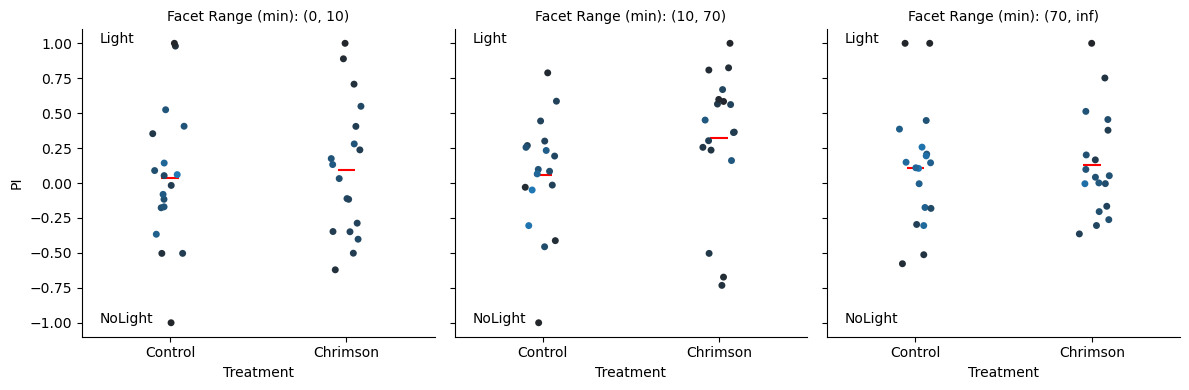

In [6]:
arena.plot_pi_facet(cutoffs=(10,70))

In [7]:
arena.run_pairwise_comparisons_facet(metric="FinalPI",cutoffs=(10,70))

############# T-Test #############
Column = FinalPI, Range Minutes = (0.00 , 10.00) 
Control vs. Chrimson: T=-0.34, p=0.73701


############# T-Test #############
Column = FinalPI, Range Minutes = (10.00 , 70.00) 
Control vs. Chrimson: T=-1.75, p=0.08969


############# T-Test #############
Column = FinalPI, Range Minutes = (70.00 , inf) 
Control vs. Chrimson: T=-0.17, p=0.86967




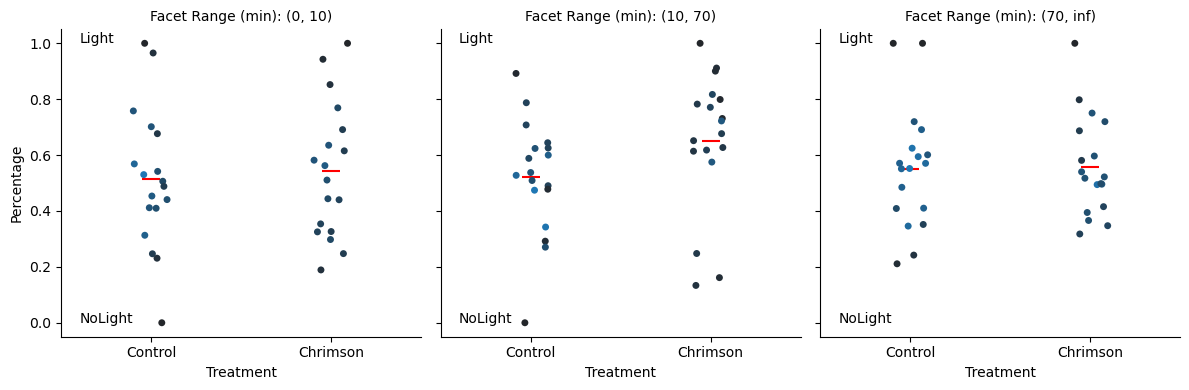

In [8]:
arena.plot_percentage_facet(cutoffs=(10,70))

In [9]:
arena.run_pairwise_comparisons_facet(metric="FinalPercentage",cutoffs=(10,70))

############# T-Test #############
Column = FinalPercentage, Range Minutes = (0.00 , 10.00) 
Control vs. Chrimson: T=-0.37, p=0.71406


############# T-Test #############
Column = FinalPercentage, Range Minutes = (10.00 , 70.00) 
Control vs. Chrimson: T=-1.73, p=0.09249


############# T-Test #############
Column = FinalPercentage, Range Minutes = (70.00 , inf) 
Control vs. Chrimson: T=-0.09, p=0.92586




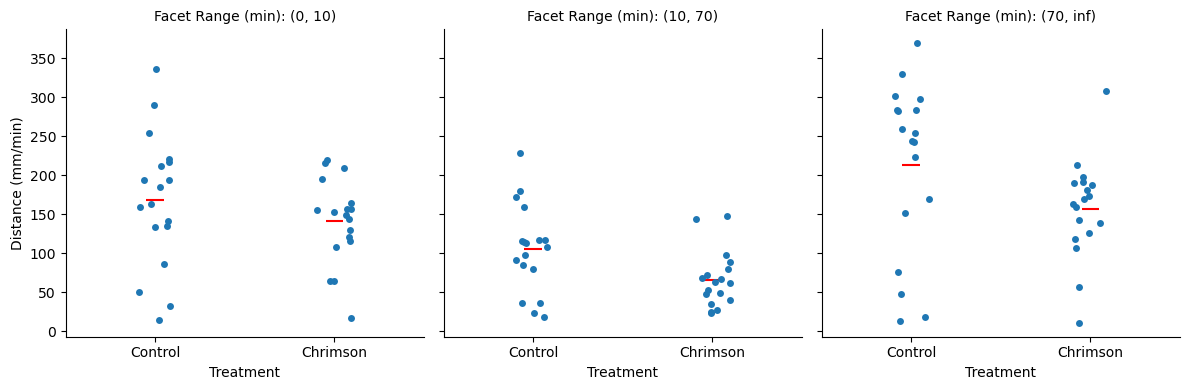

In [10]:
arena.plot_totaldistance_facet(cutoffs=(10,70))

In [11]:
arena.run_pairwise_comparisons_facet(metric="TotalDistance",cutoffs=(10,70))

############# T-Test #############
Column = TotalDistance, Range Minutes = (0.00 , 10.00) 
Control vs. Chrimson: T=1.12, p=0.27111


############# T-Test #############
Column = TotalDistance, Range Minutes = (10.00 , 70.00) 
Control vs. Chrimson: T=2.48, p=0.01841


############# T-Test #############
Column = TotalDistance, Range Minutes = (70.00 , inf) 
Control vs. Chrimson: T=1.89, p=0.06705




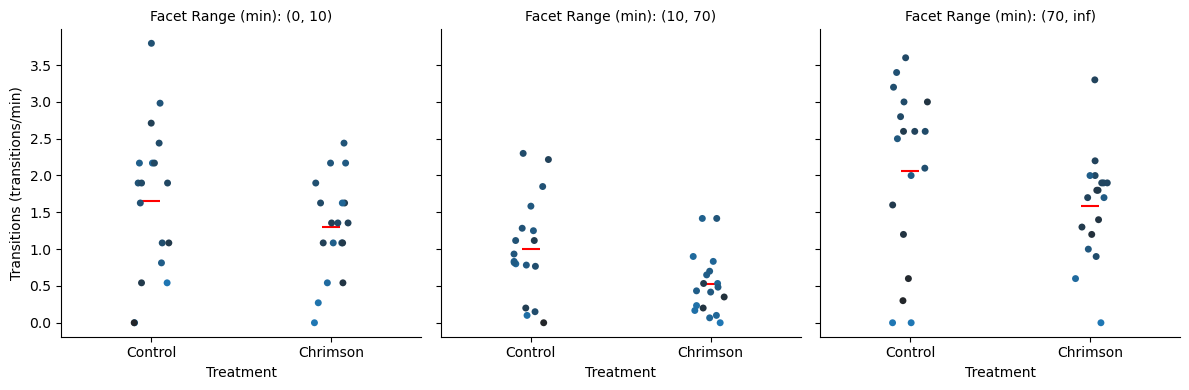

In [12]:
arena.plot_transitions_facet(cutoffs=(10,70))

In [13]:
arena.run_pairwise_comparisons_facet(metric="Transitions",cutoffs=(10,70))

############# T-Test #############
Column = Transitions, Range Minutes = (0.00 , 10.00) 
Control vs. Chrimson: T=1.24, p=0.22288


############# T-Test #############
Column = Transitions, Range Minutes = (10.00 , 70.00) 
Control vs. Chrimson: T=2.58, p=0.01452


############# T-Test #############
Column = Transitions, Range Minutes = (70.00 , inf) 
Control vs. Chrimson: T=1.46, p=0.15440




**Tracker plots:** These show, for each tracker individually, the progression of PI and Percentage showing cumulative values and time-dependent values

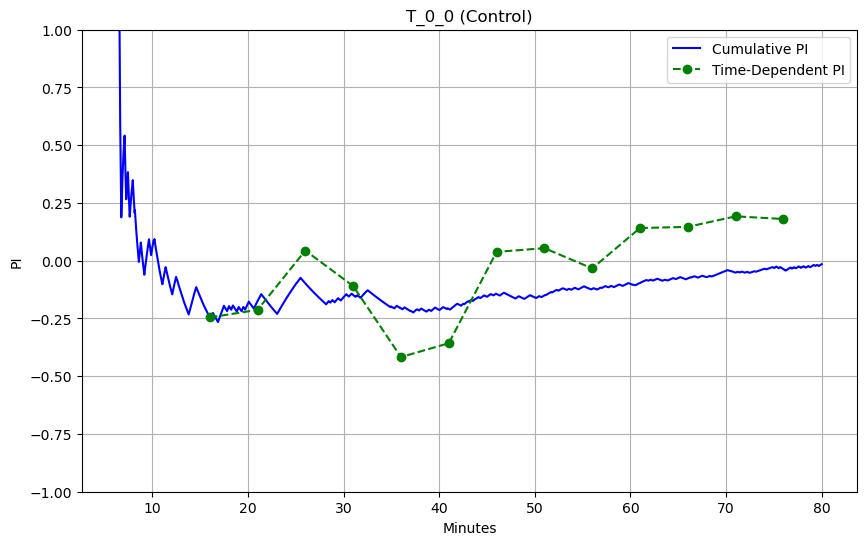

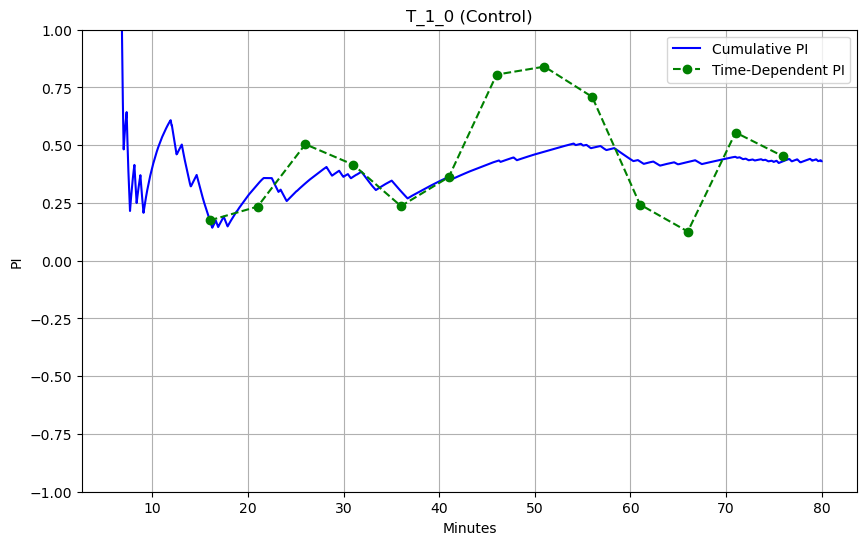

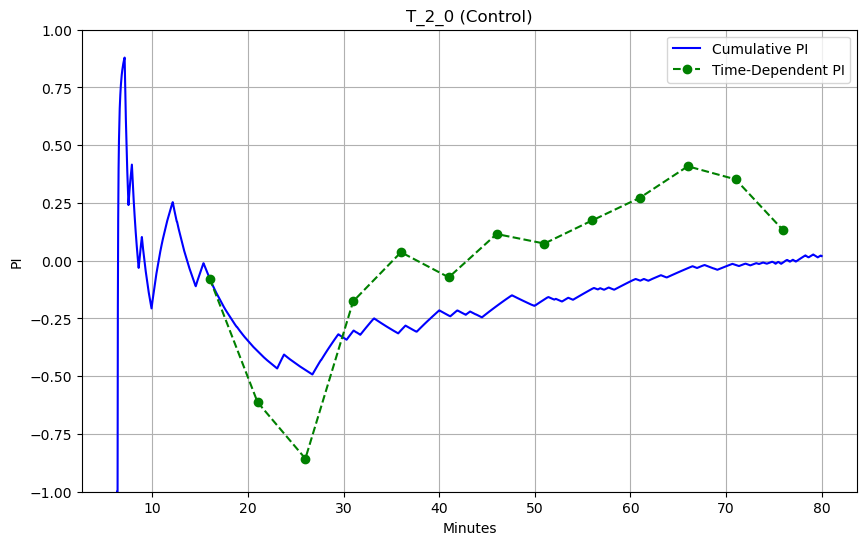

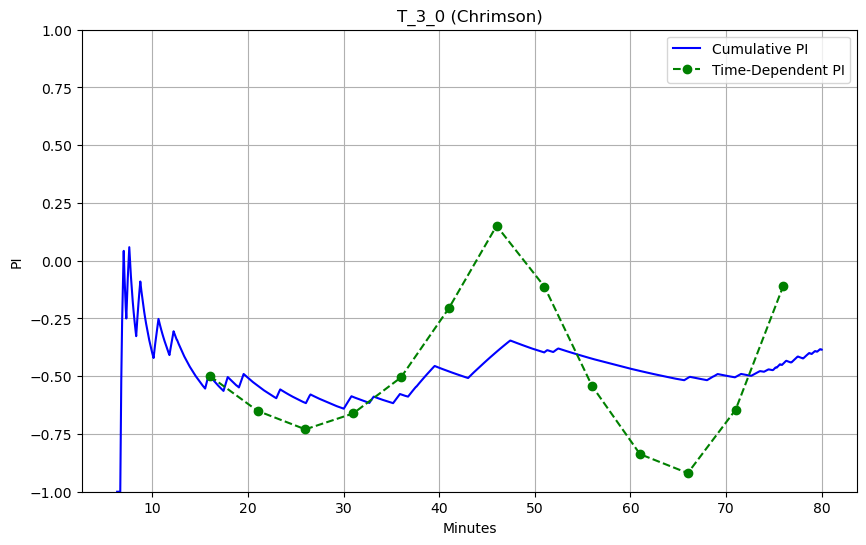

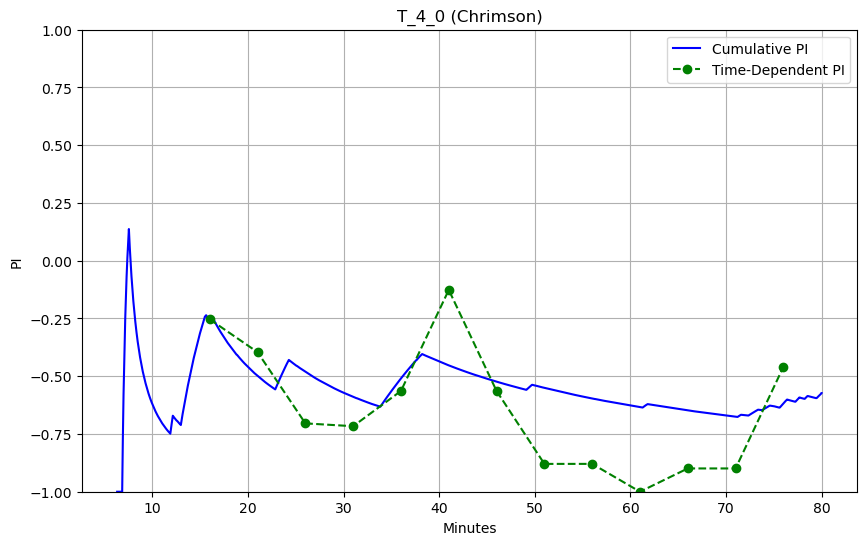

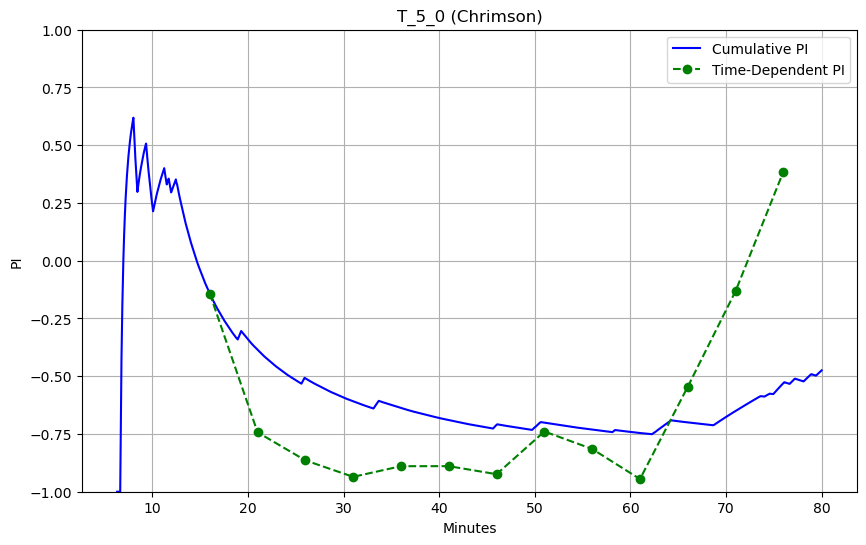

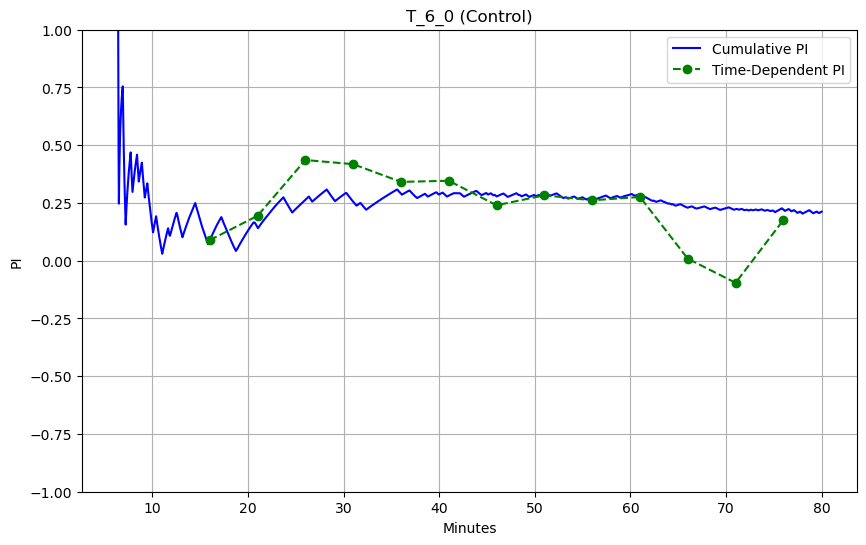

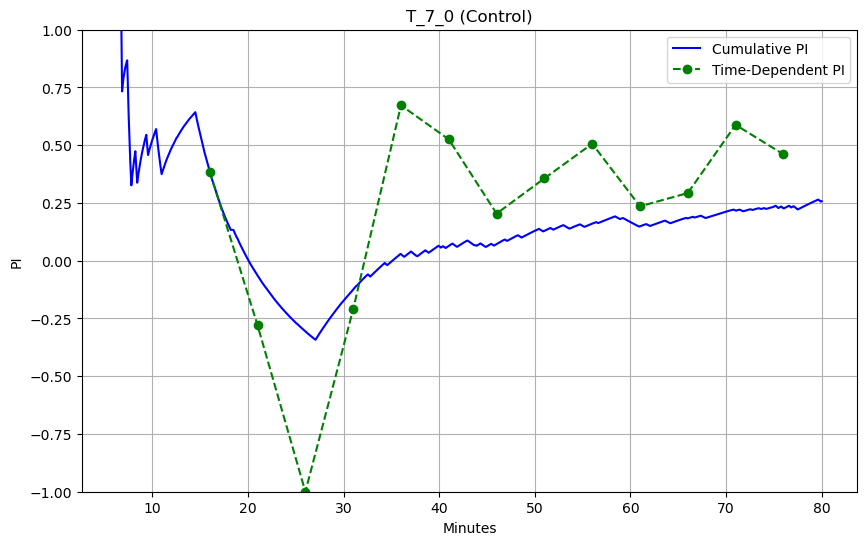

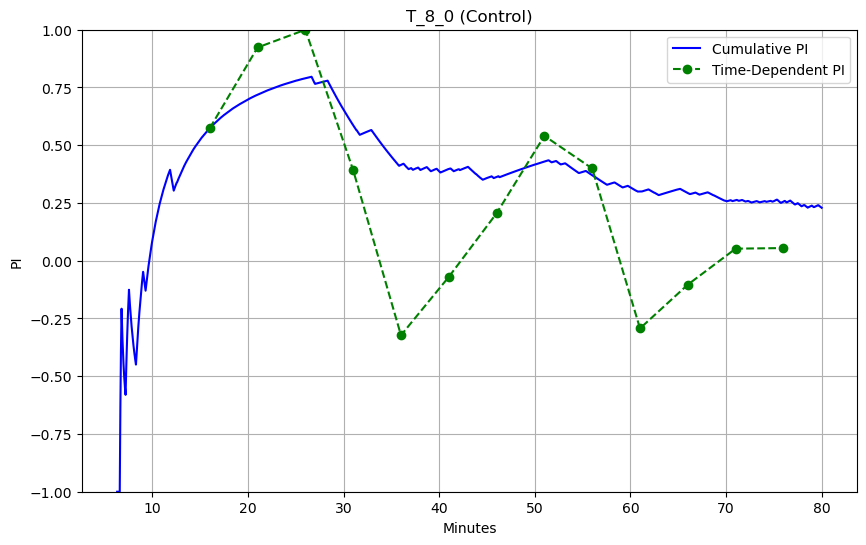

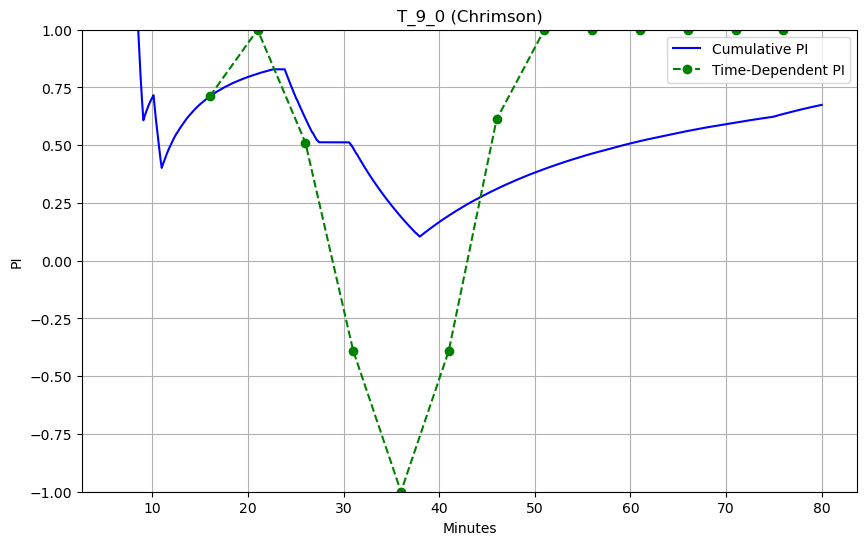

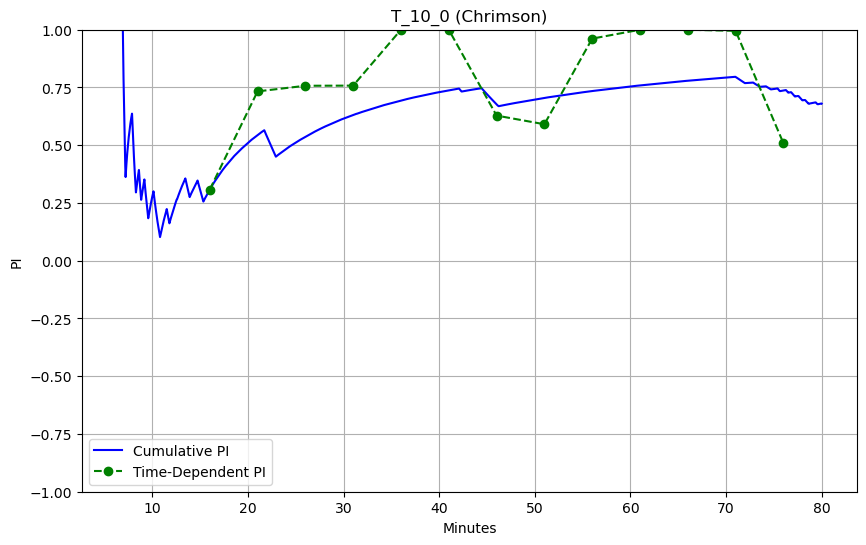

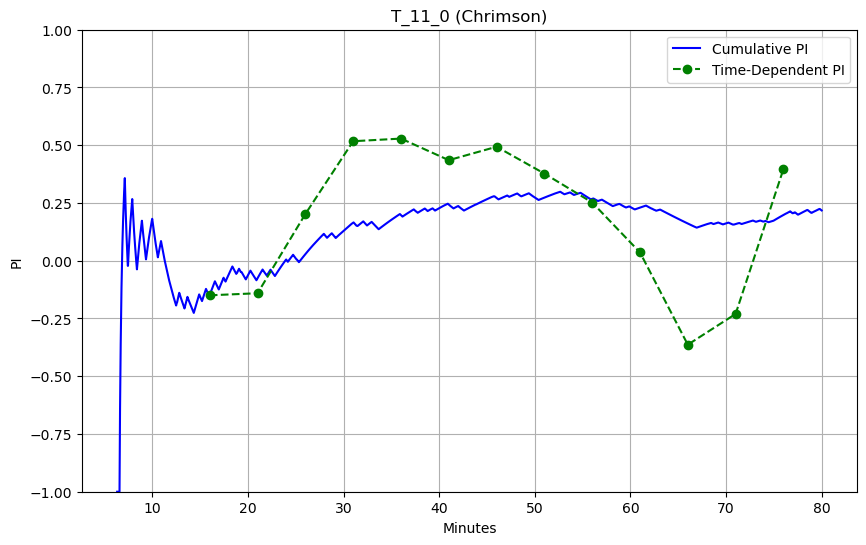

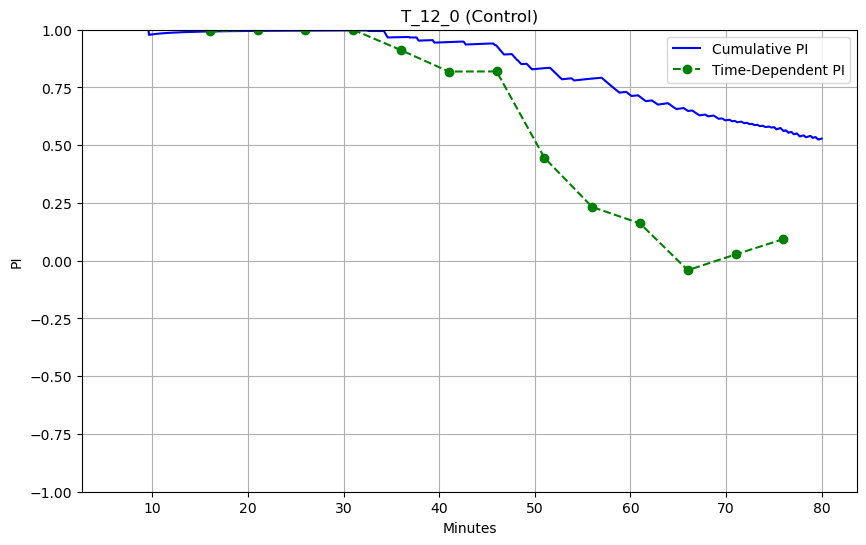

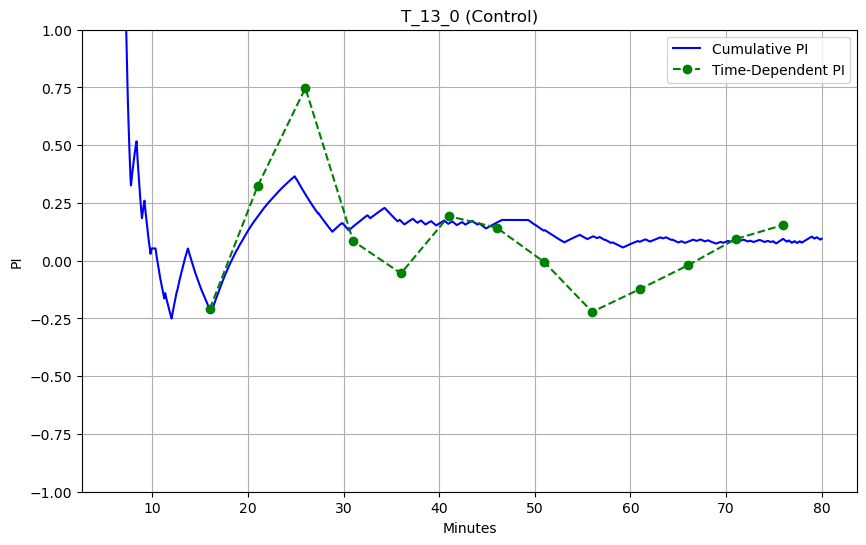

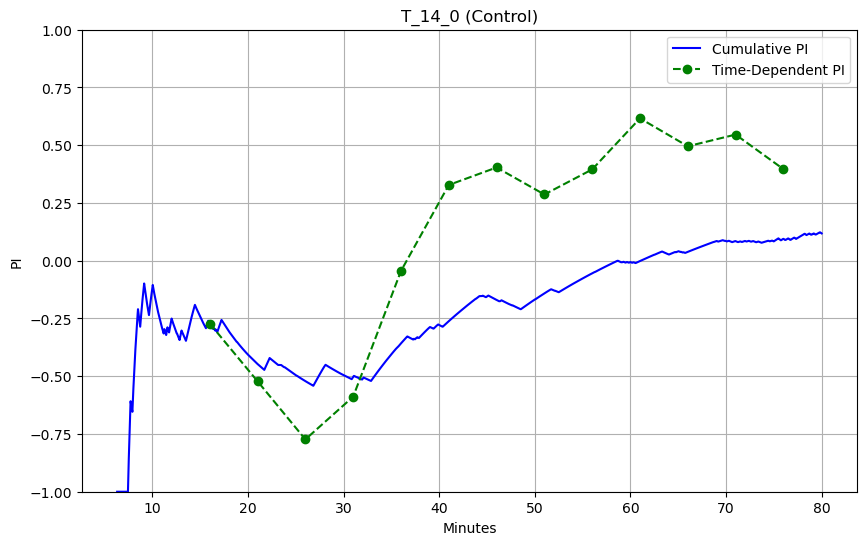

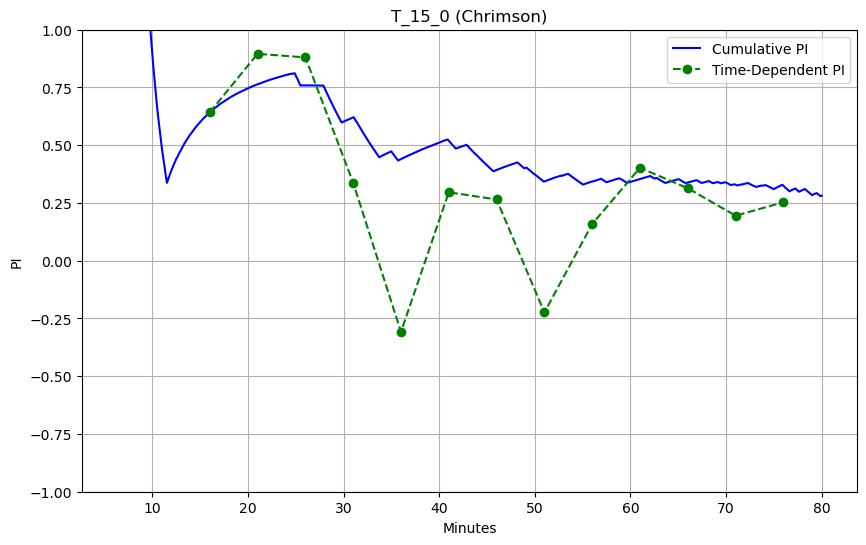

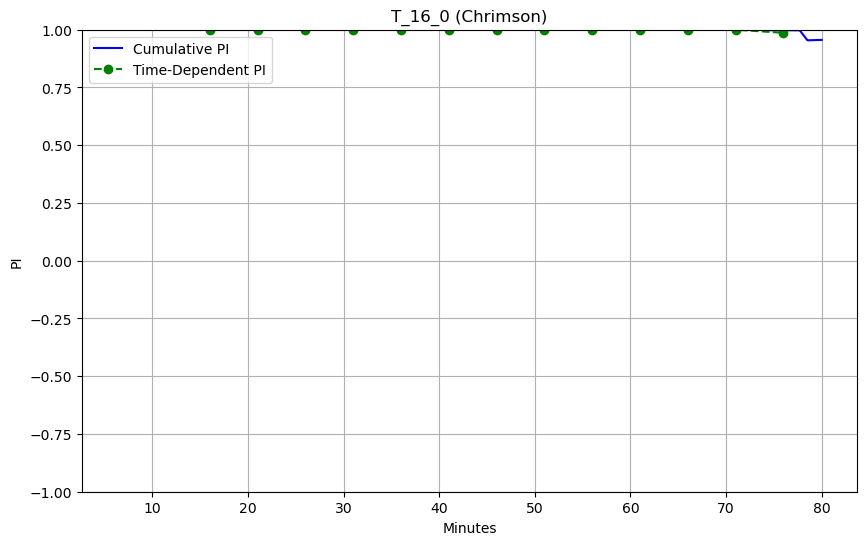

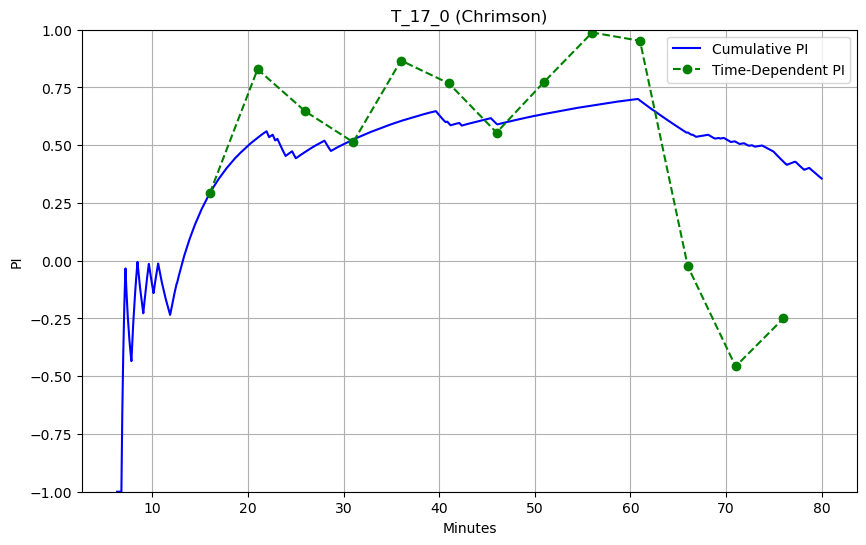

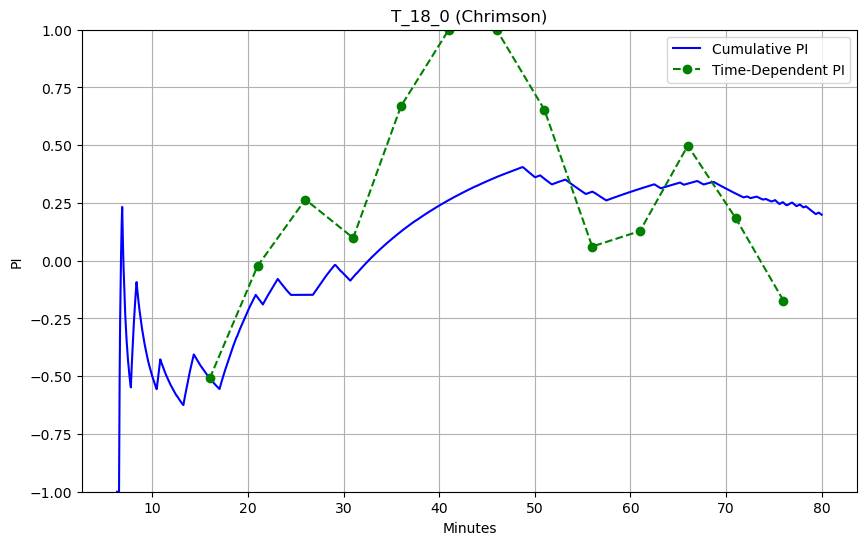

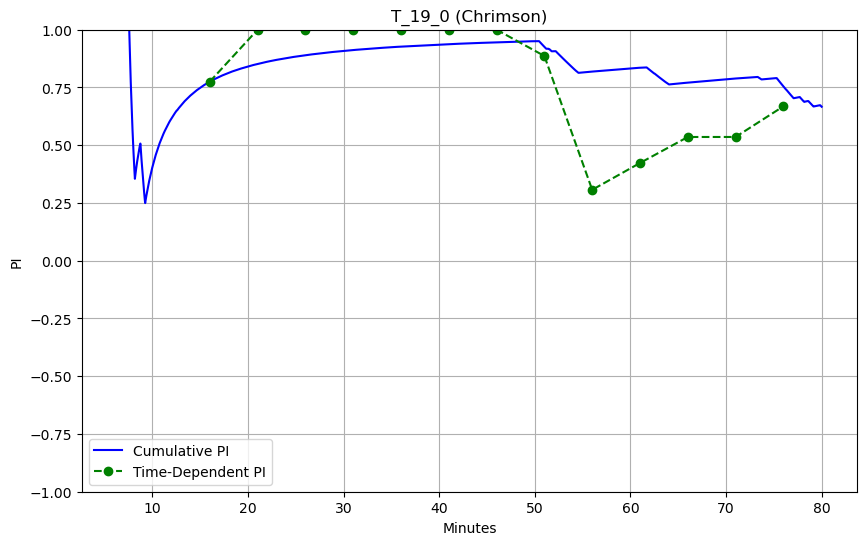

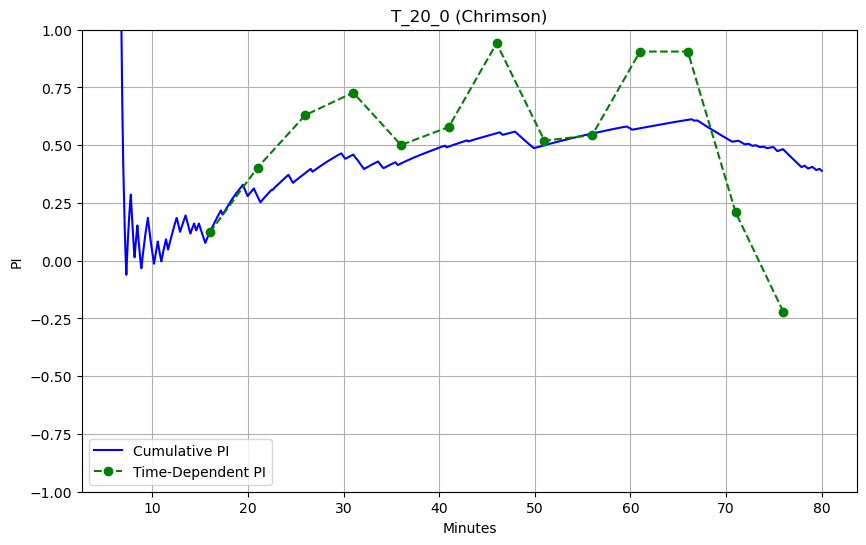

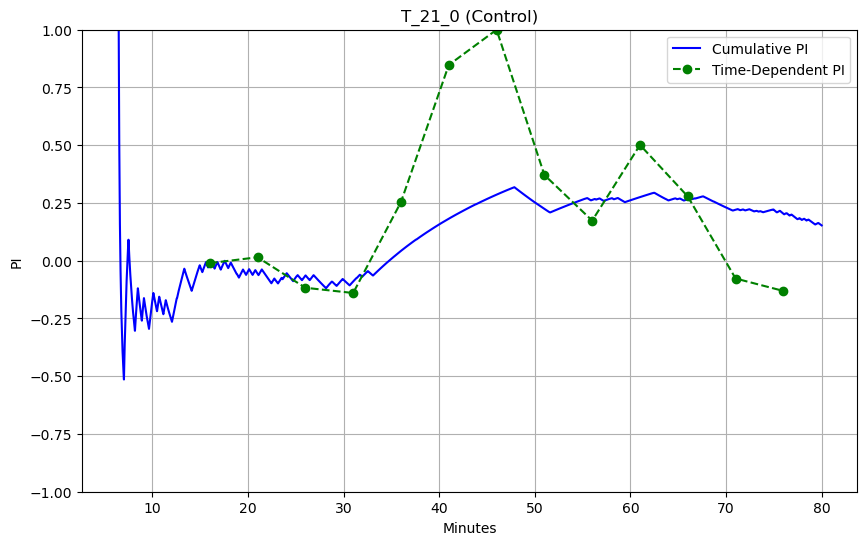

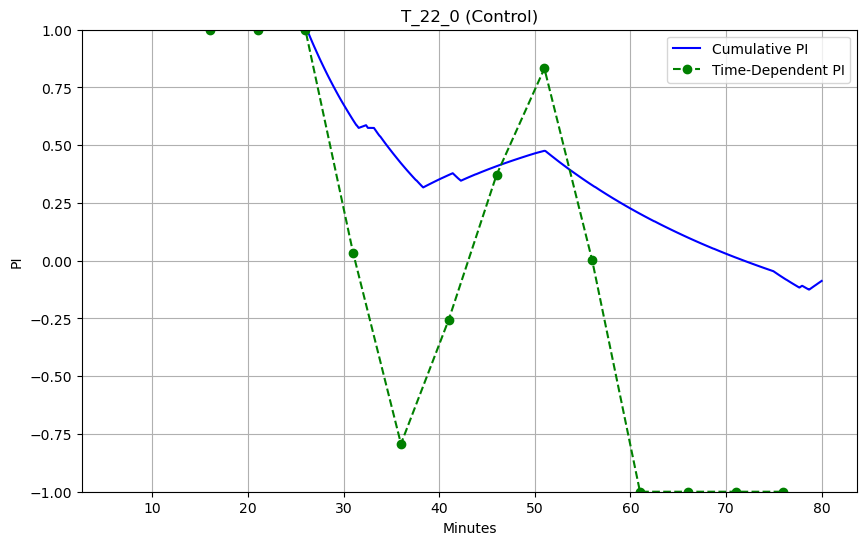

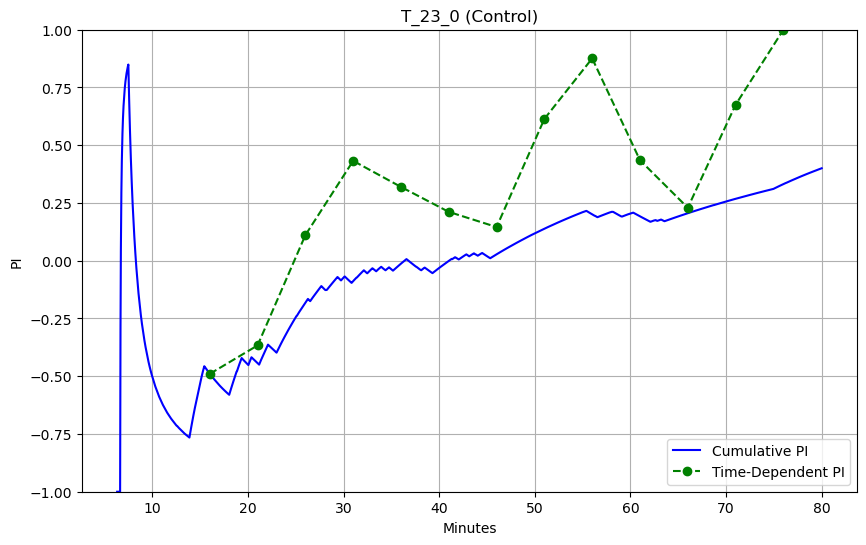

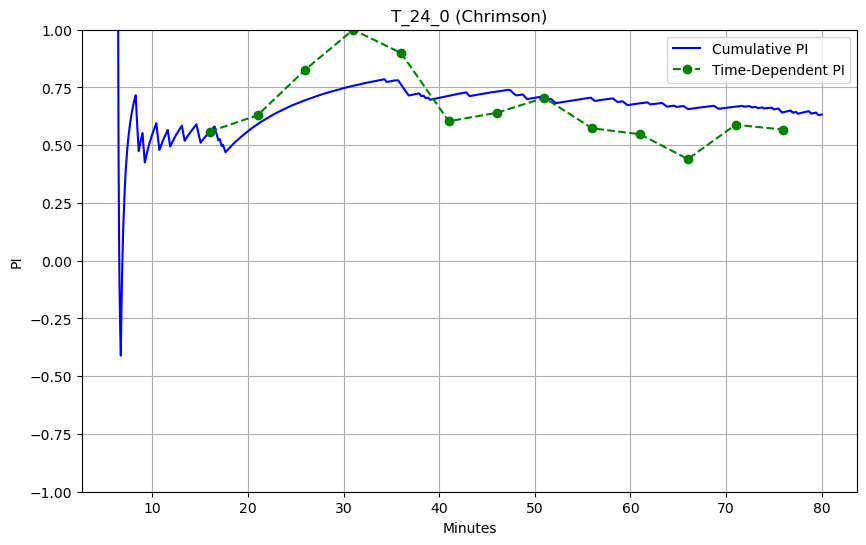

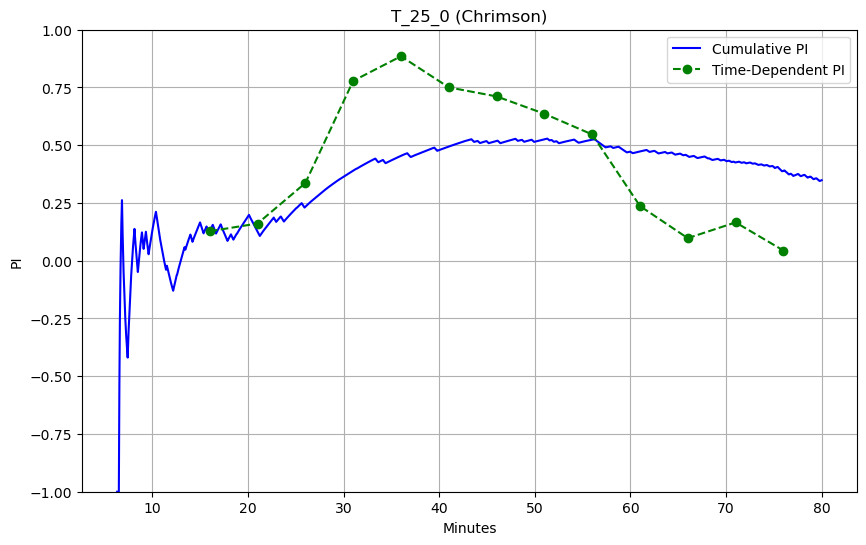

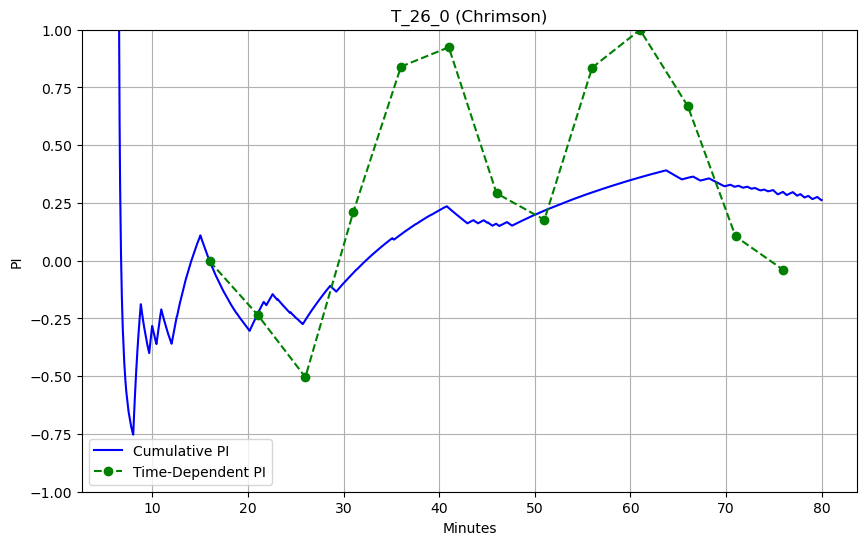

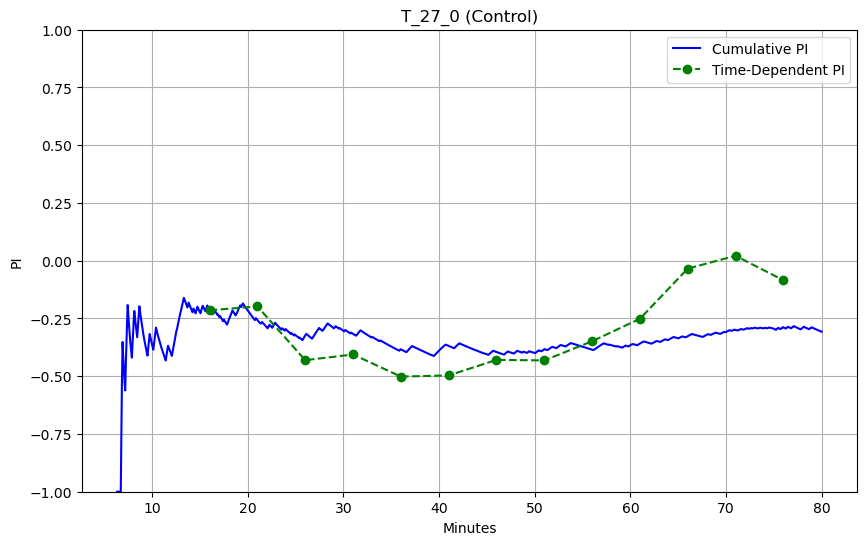

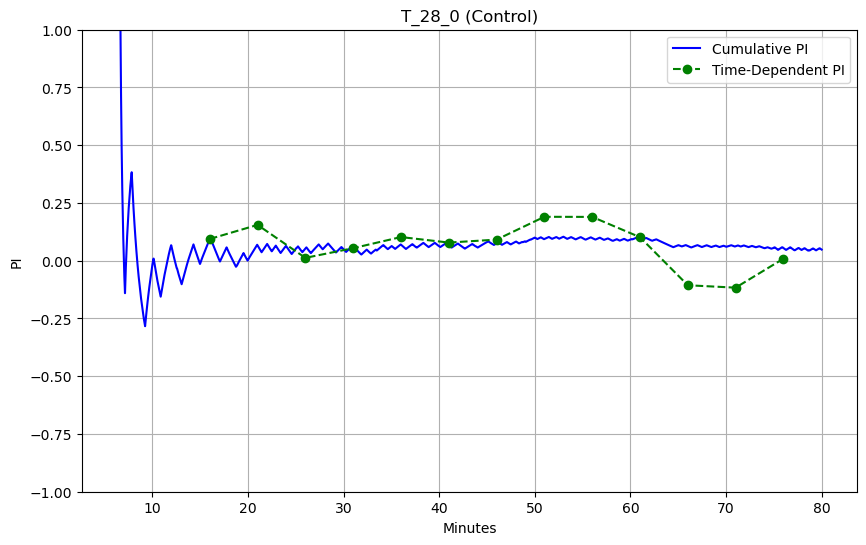

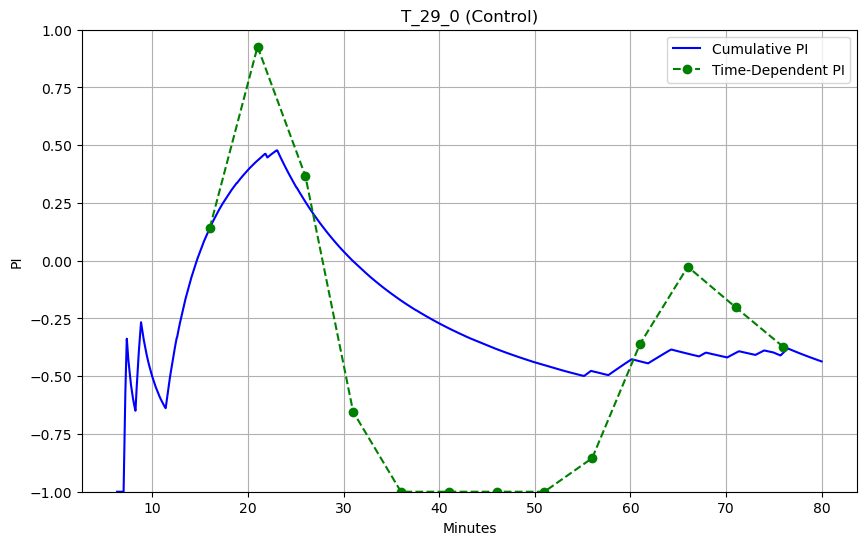

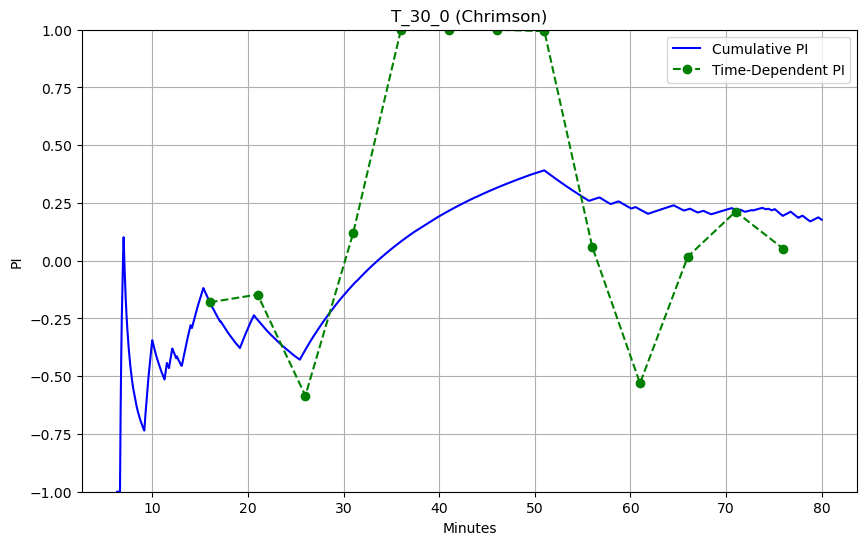

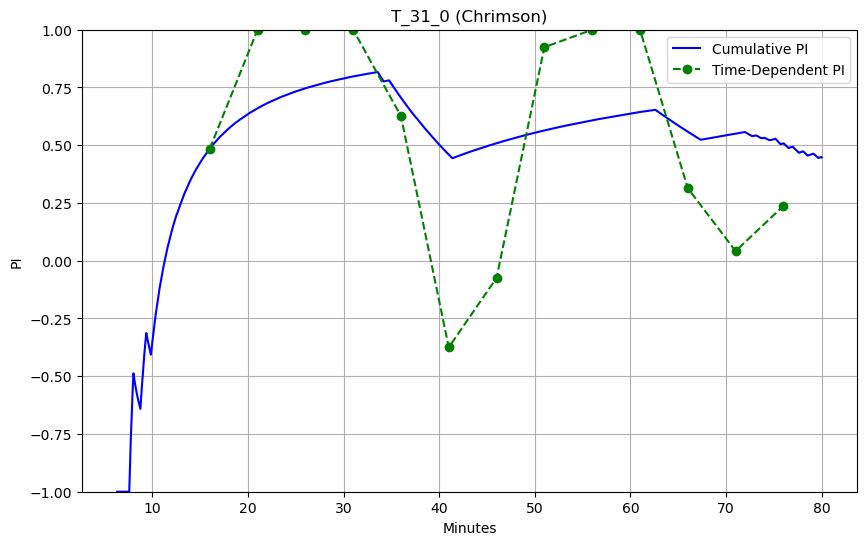

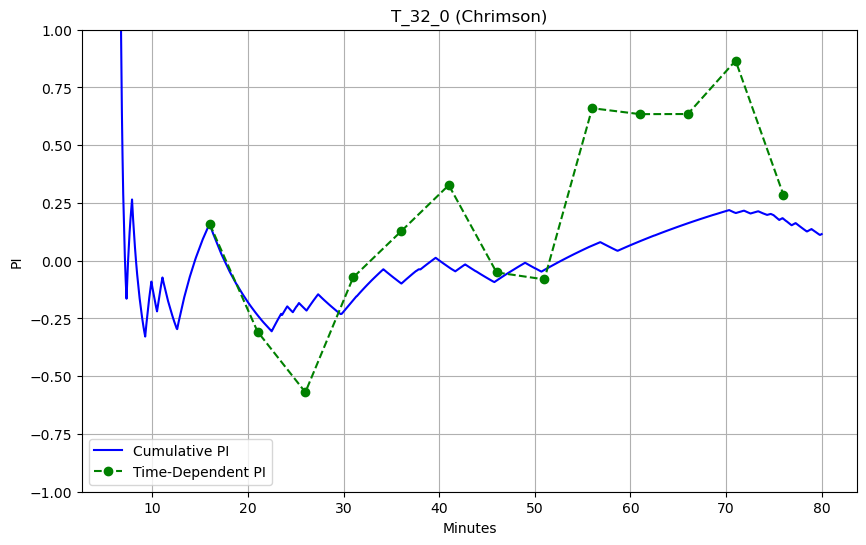

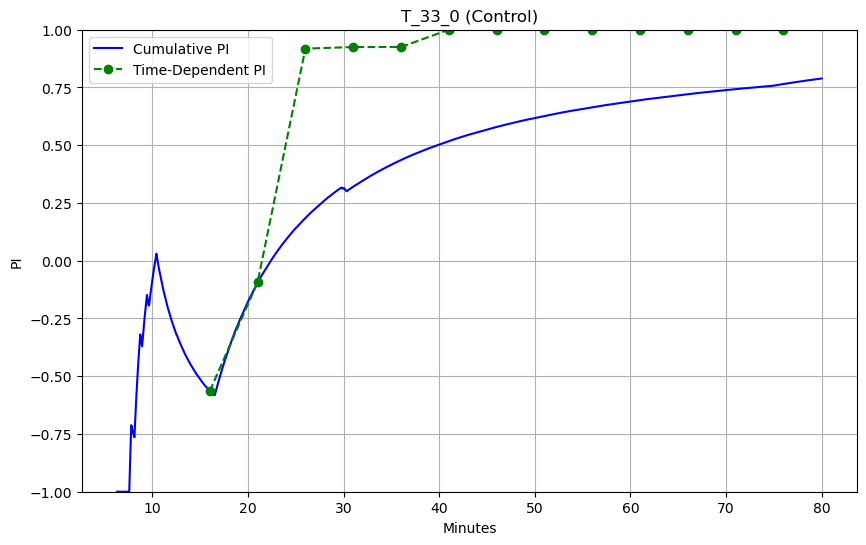

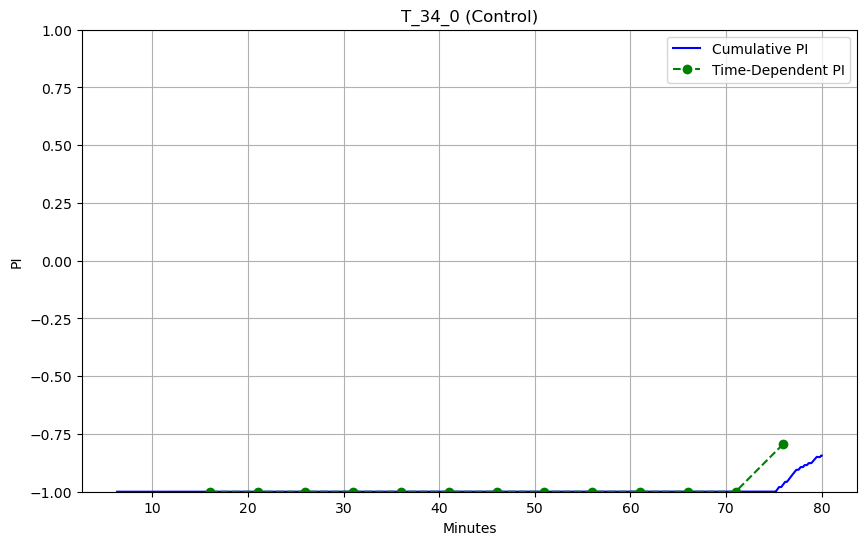

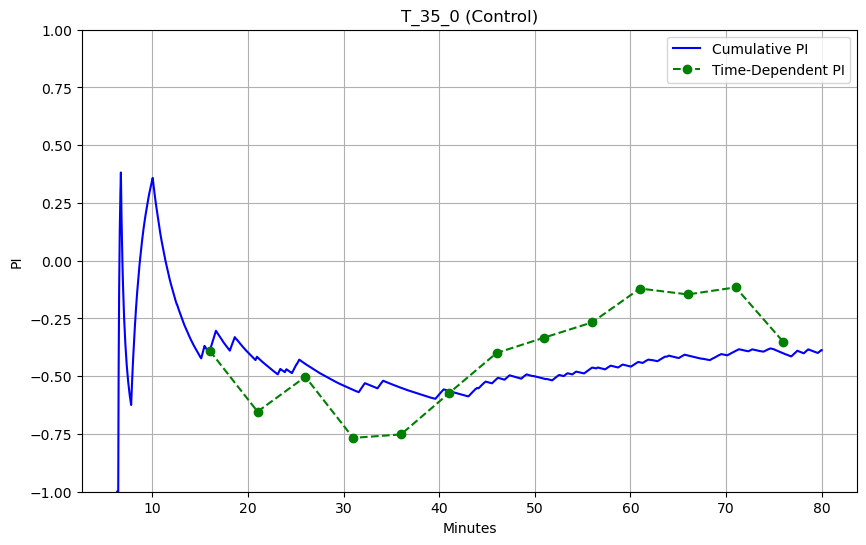

In [14]:
arena.plot_trackers_pis()

**Positional Plots:** Show the X positions of each tracker as a function of time.

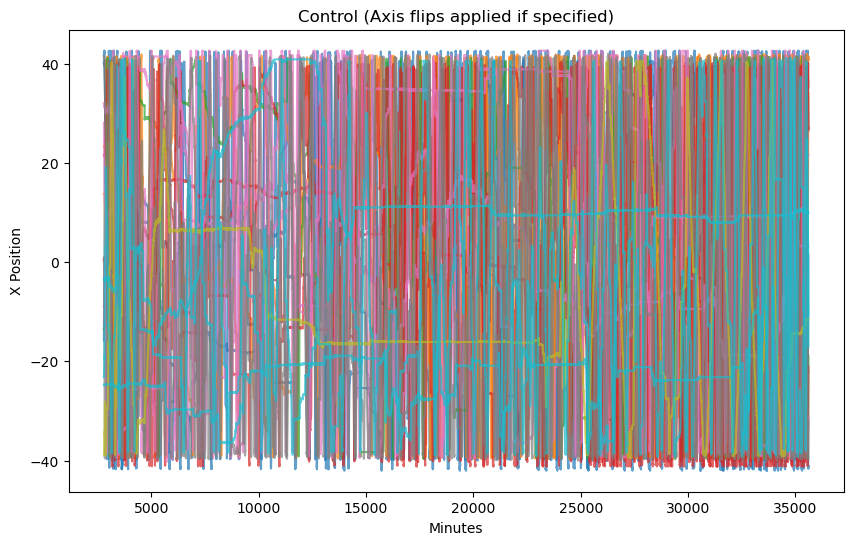

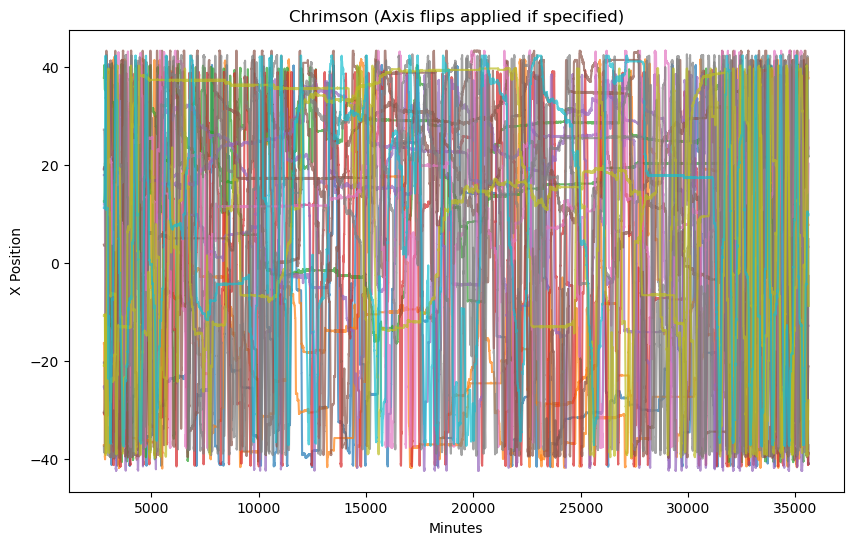

In [15]:
arena.plot_trackers_x(one_plot=True)

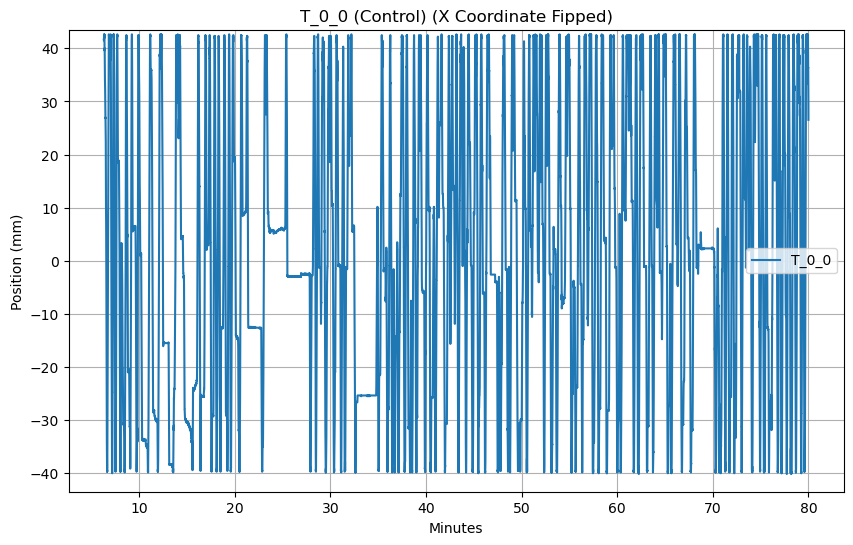

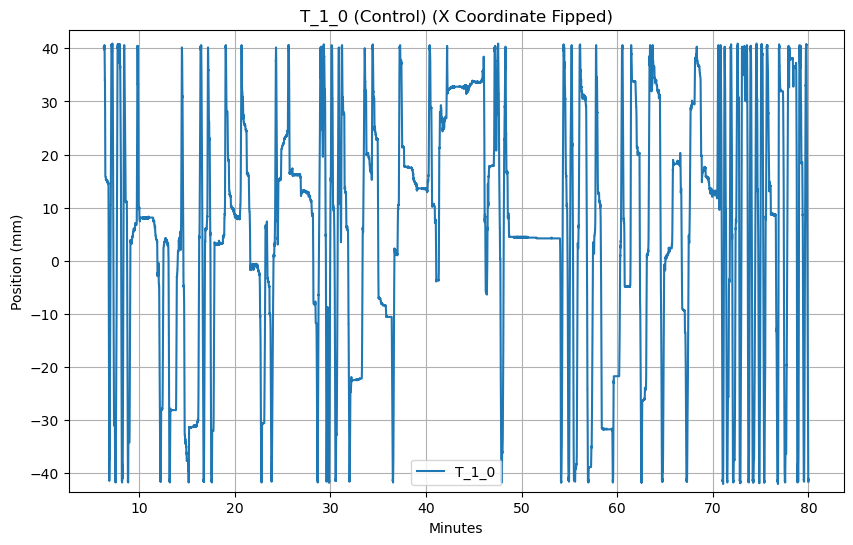

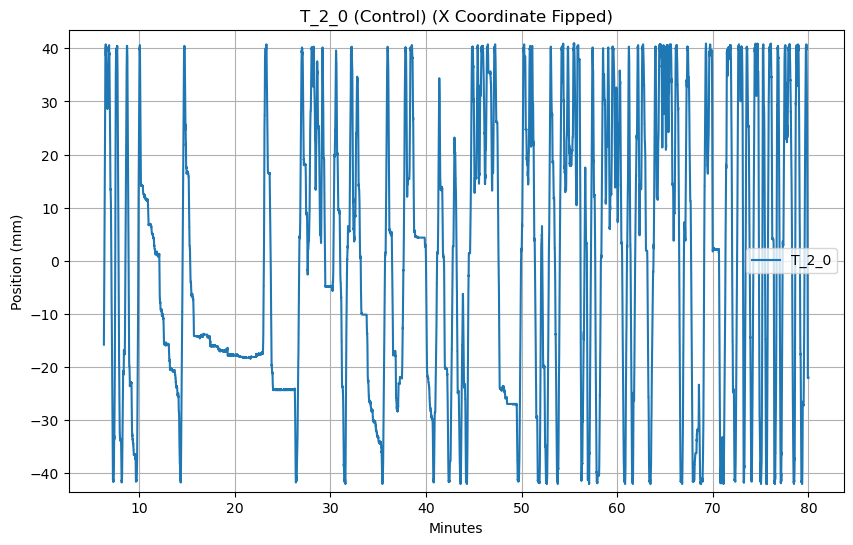

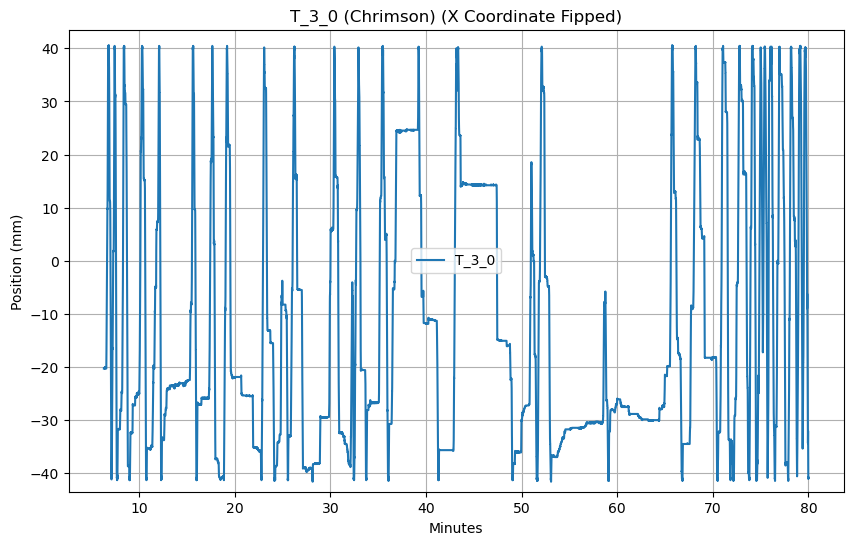

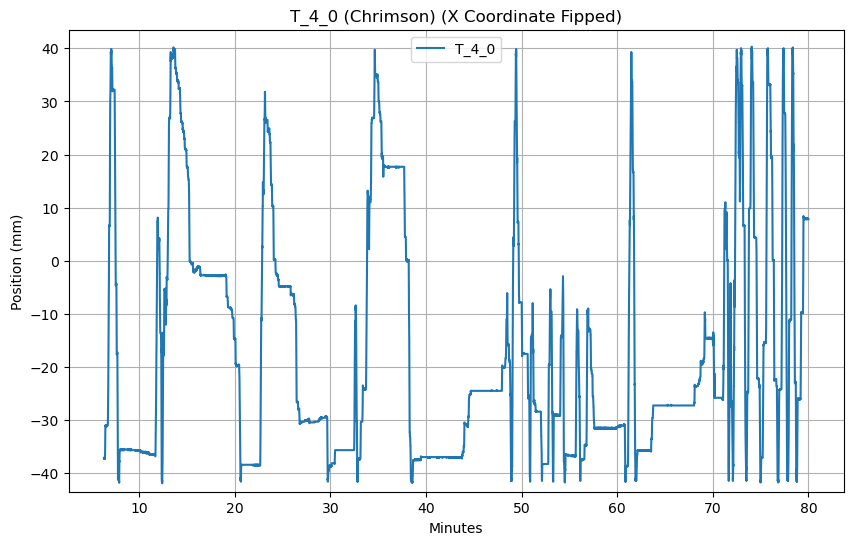

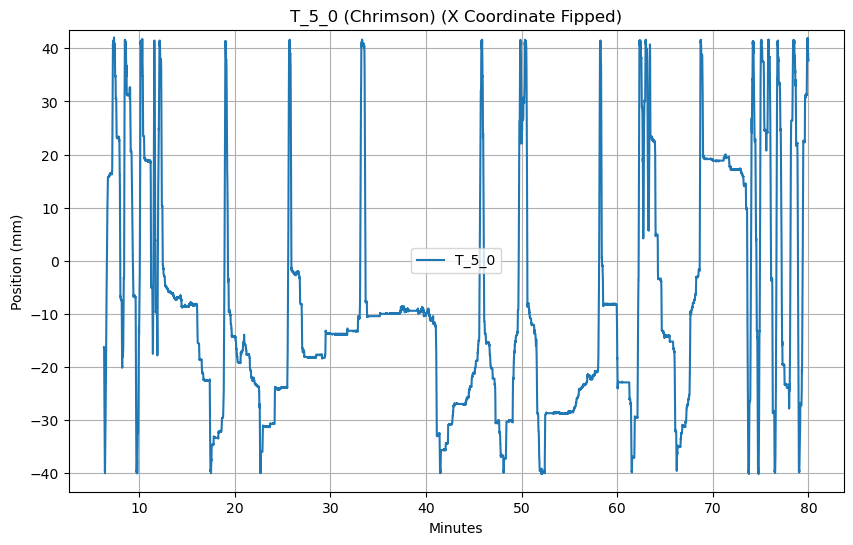

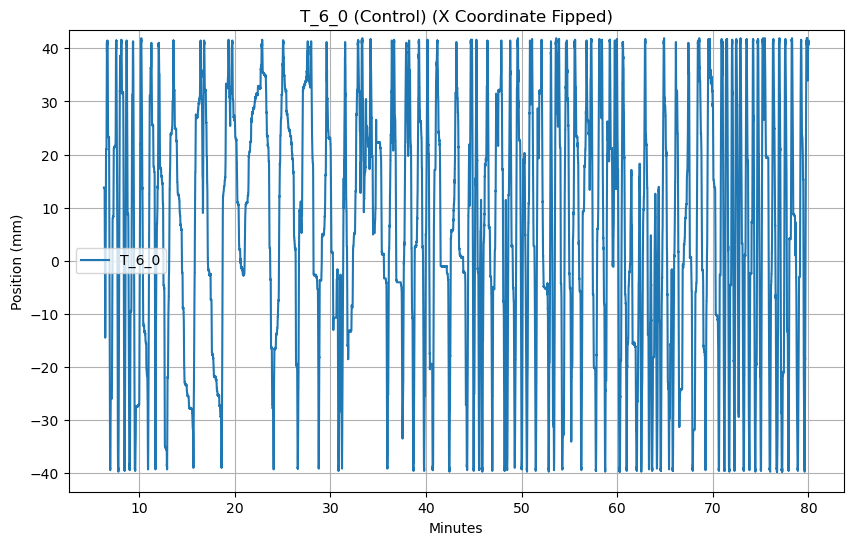

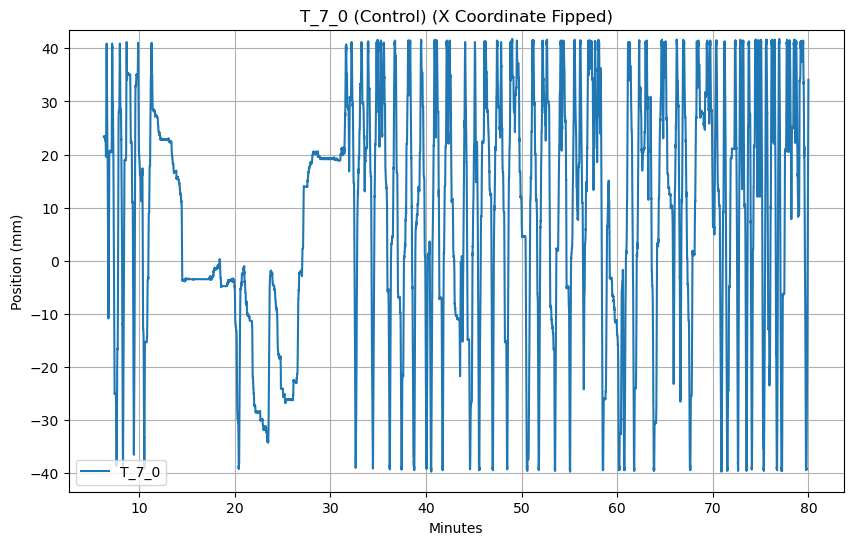

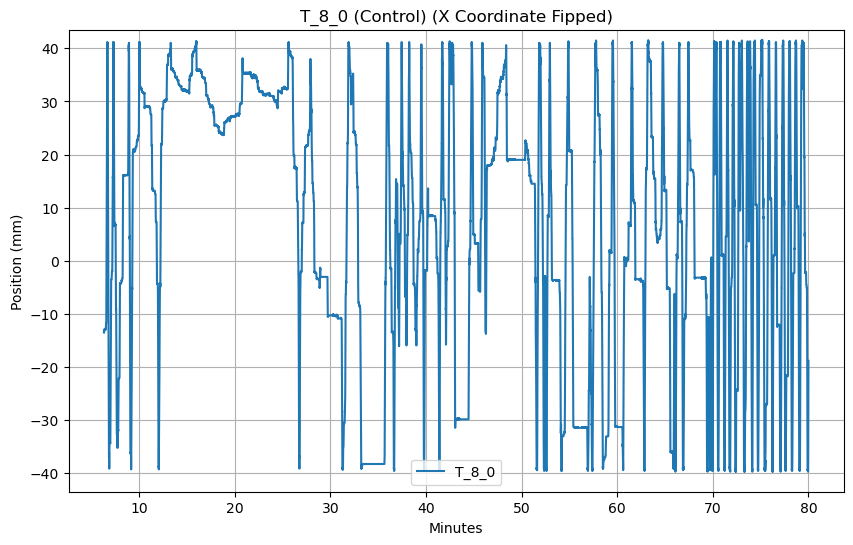

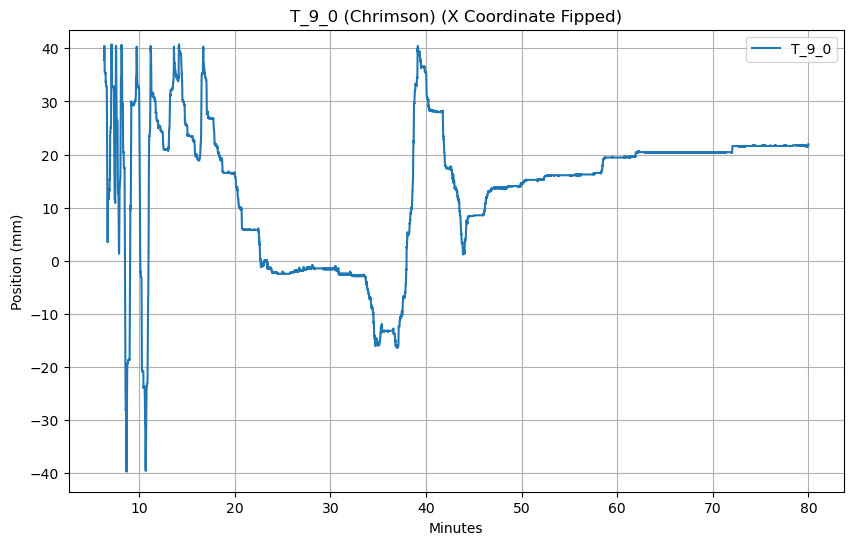

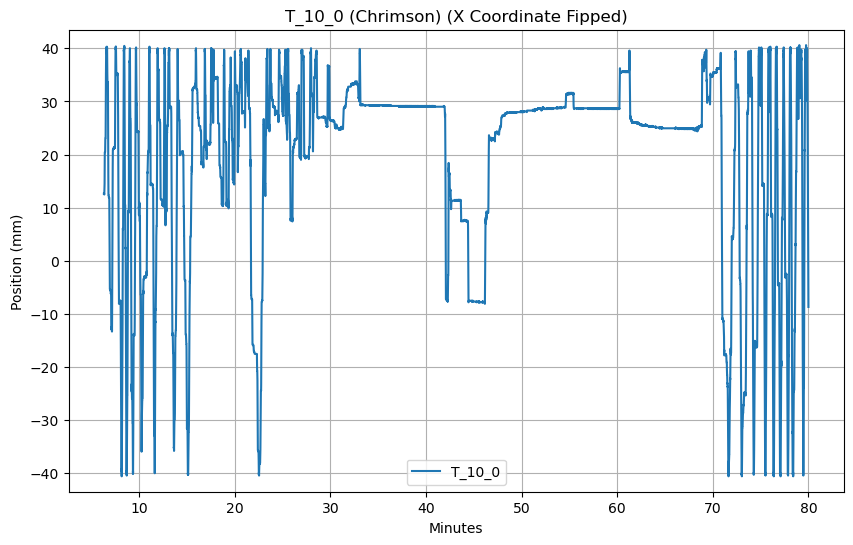

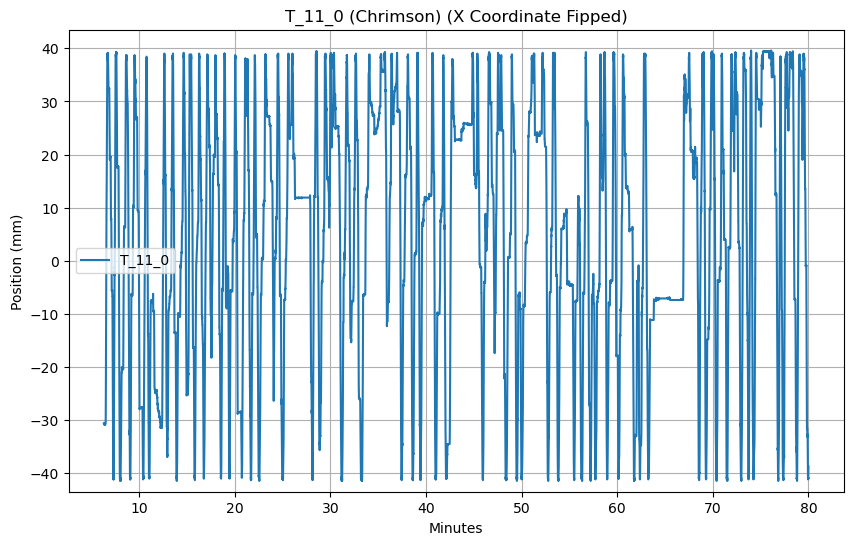

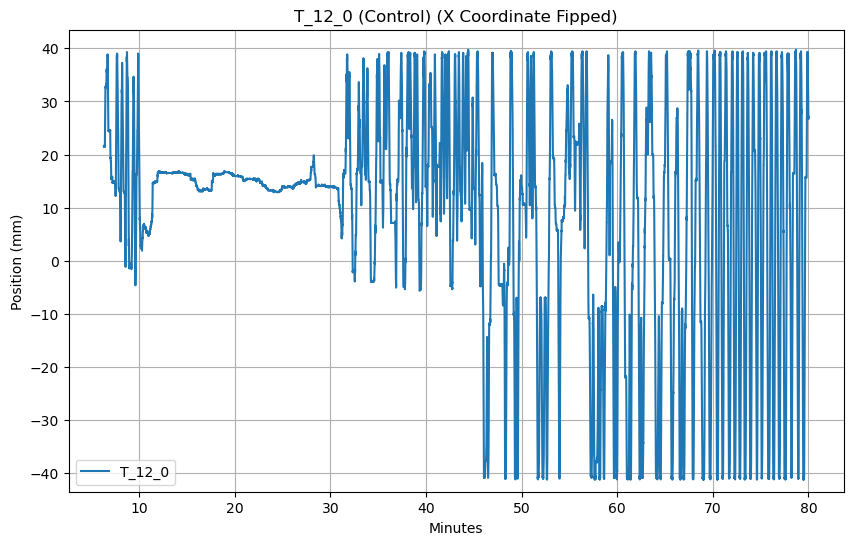

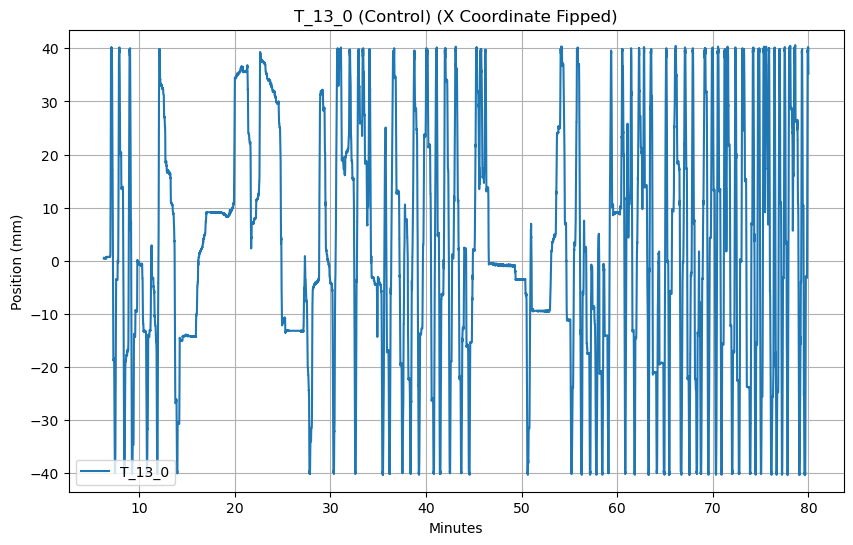

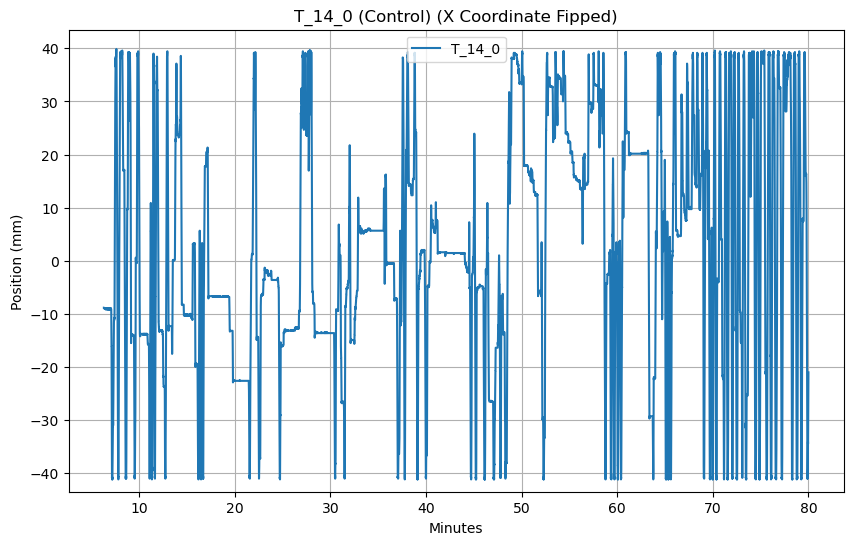

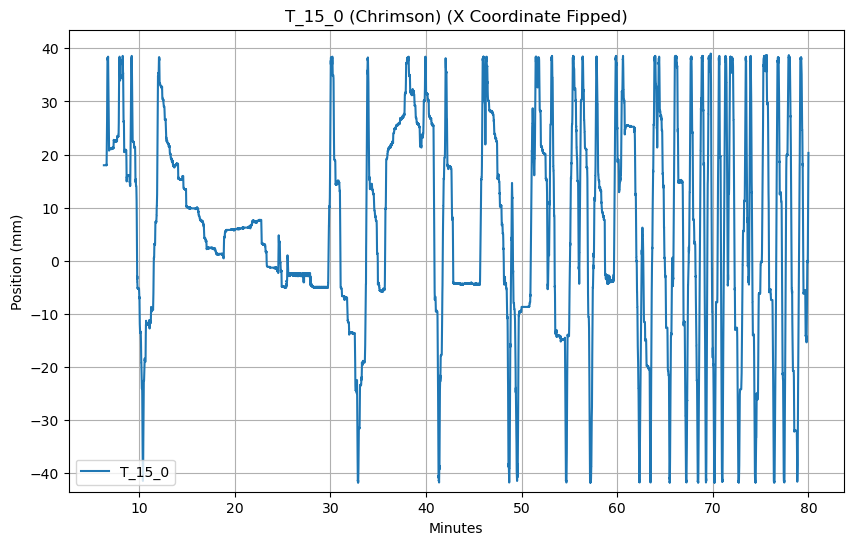

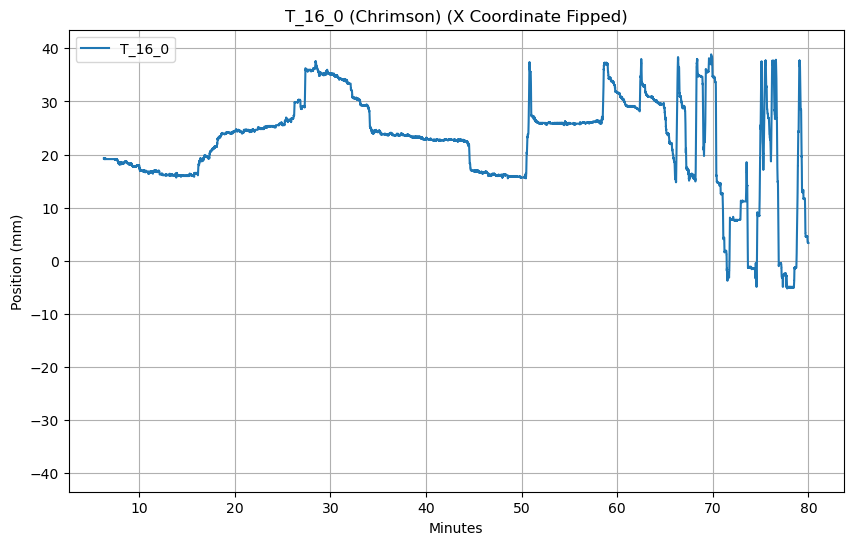

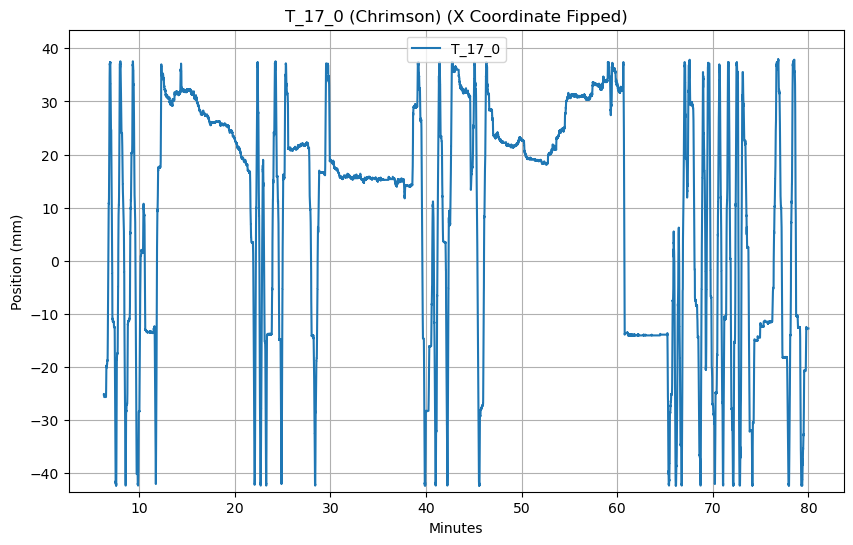

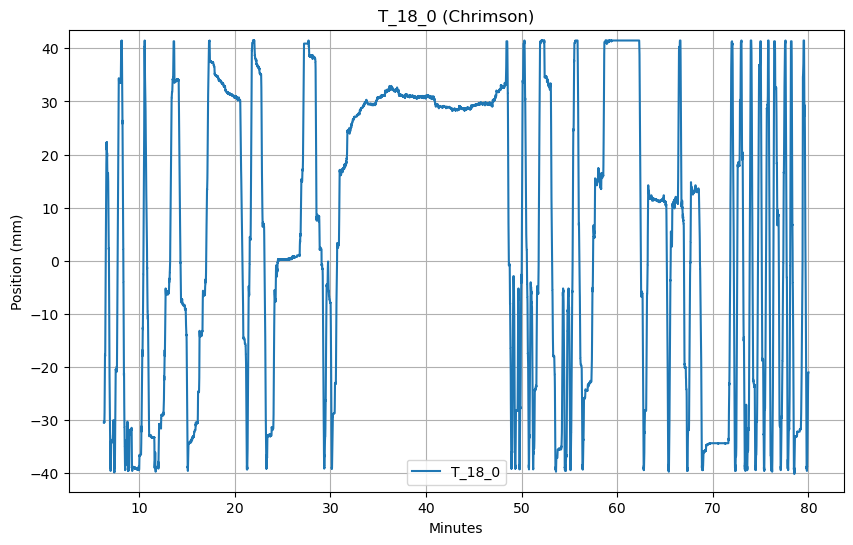

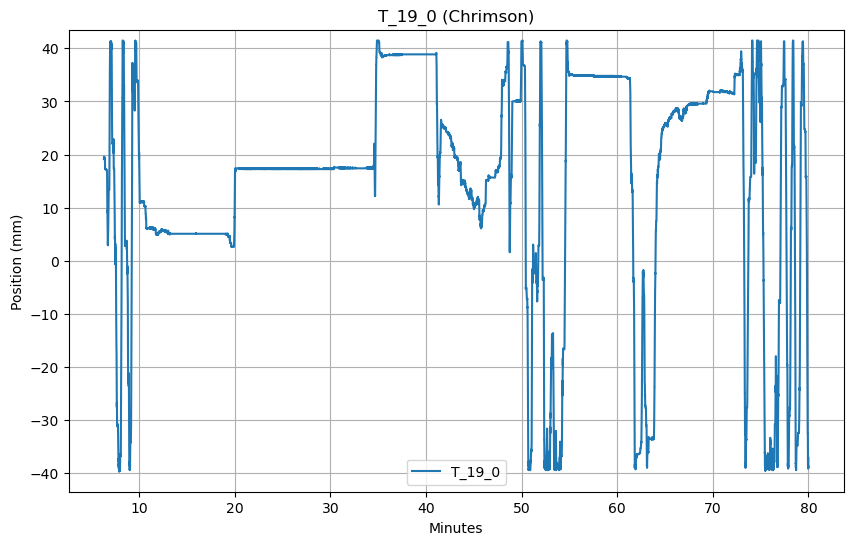

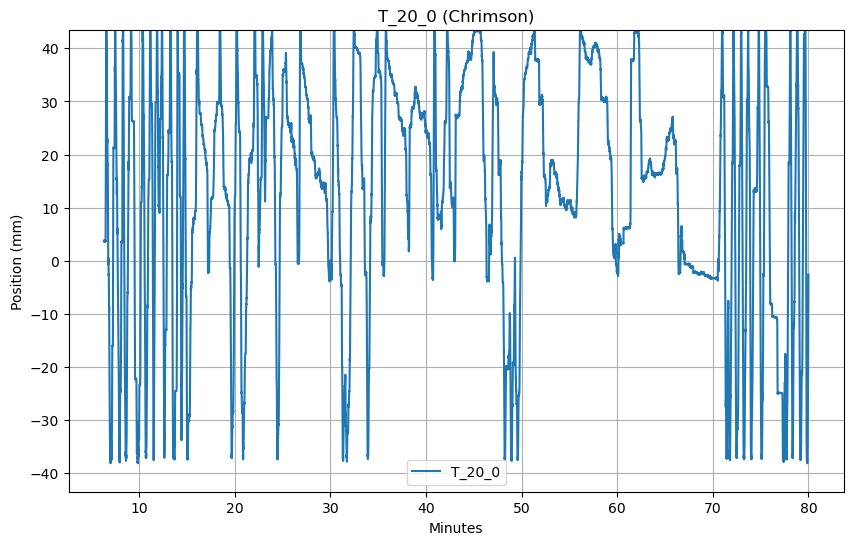

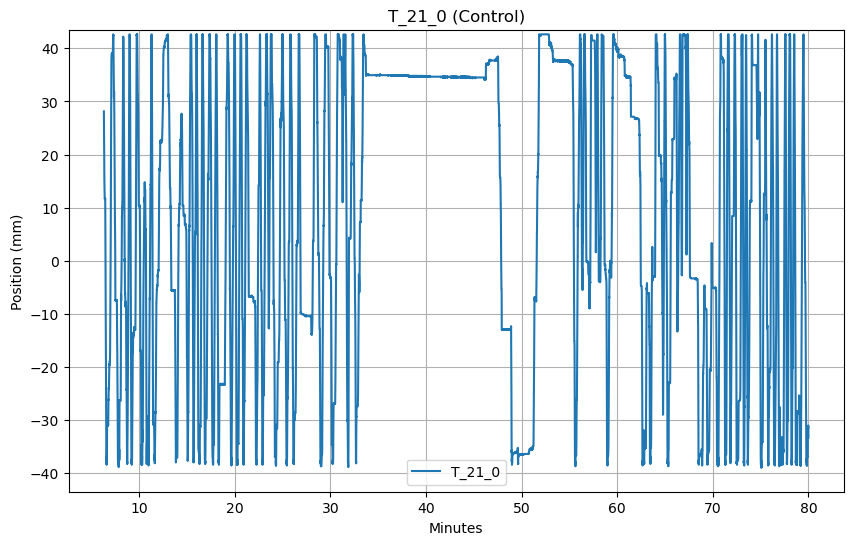

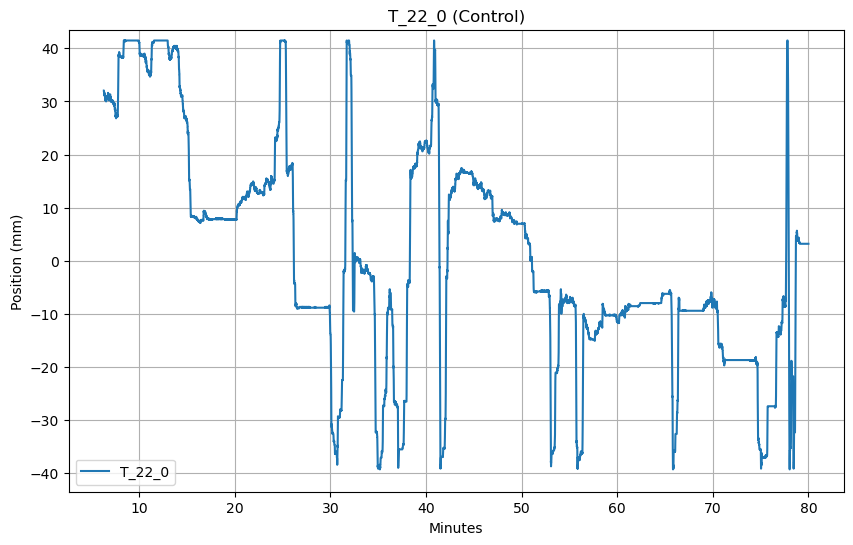

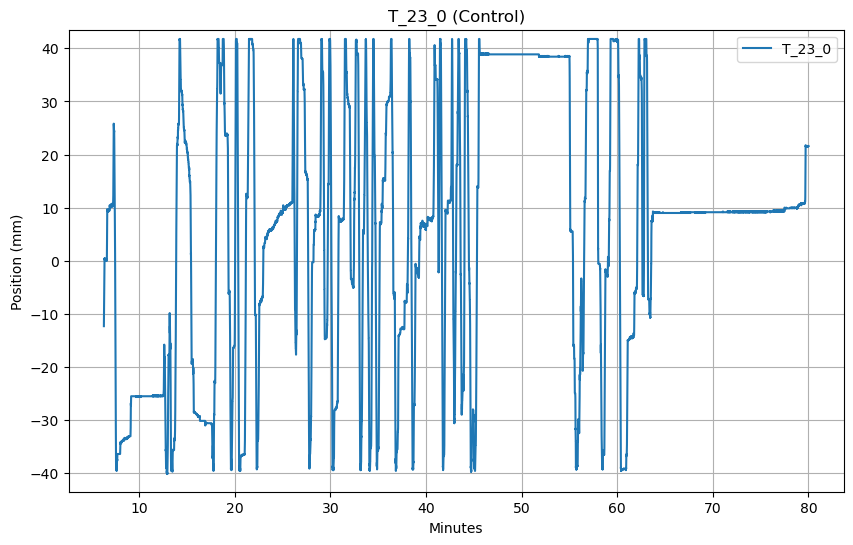

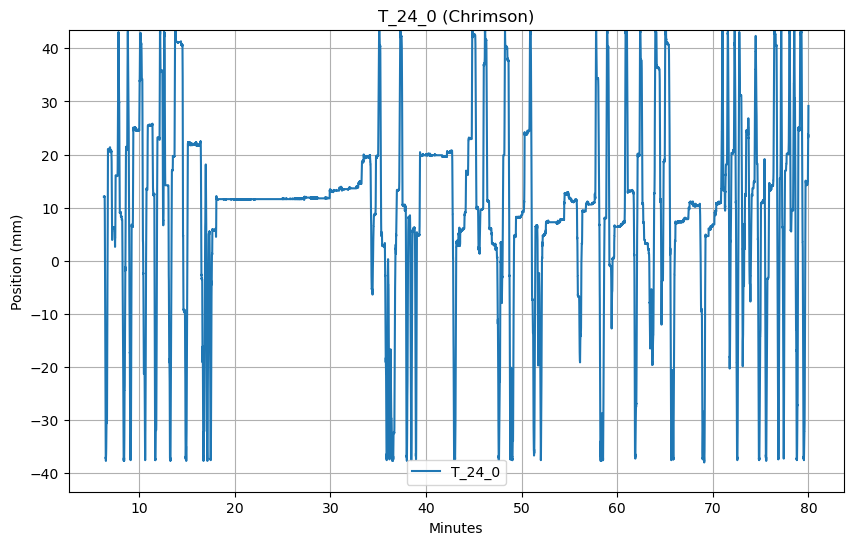

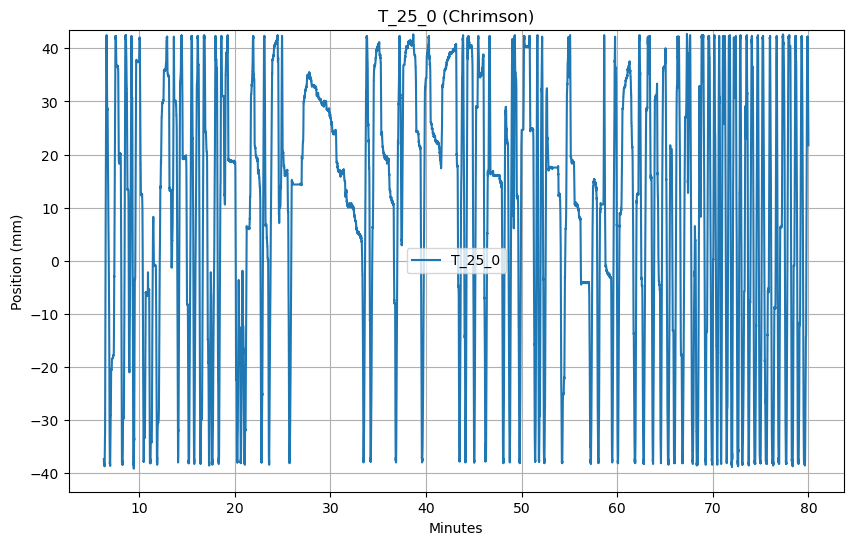

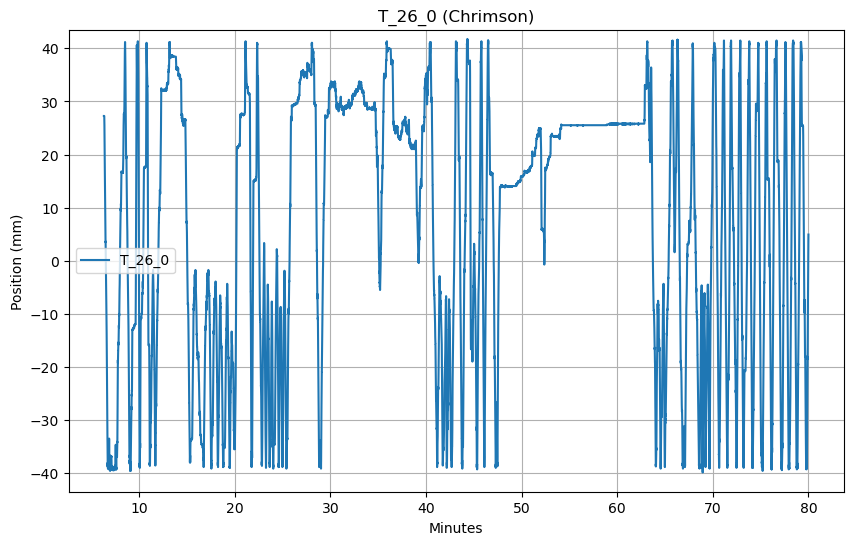

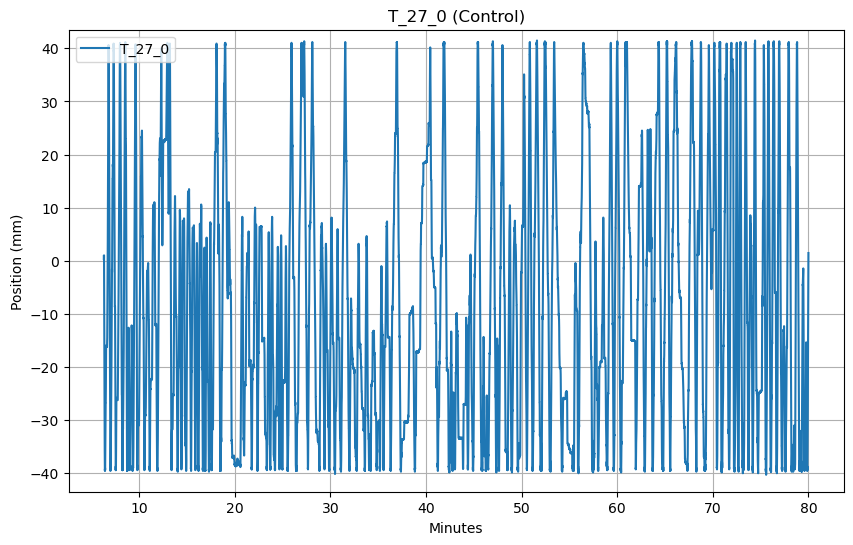

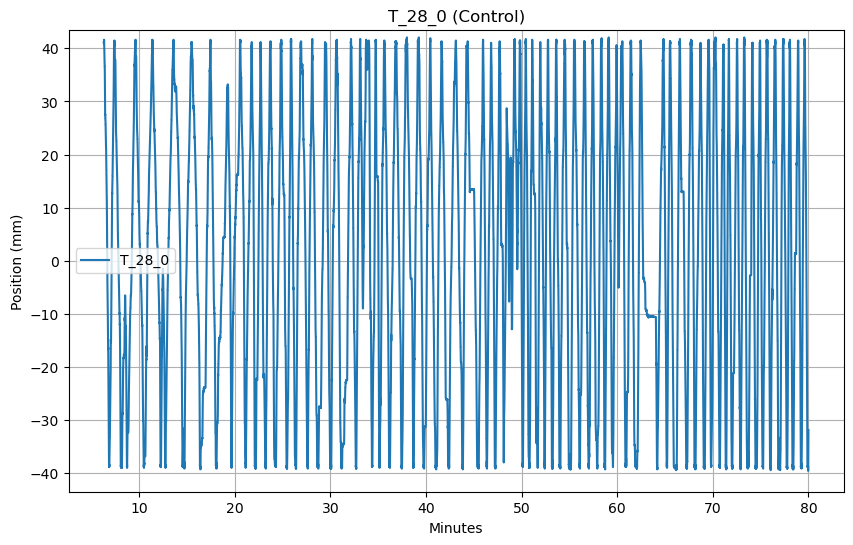

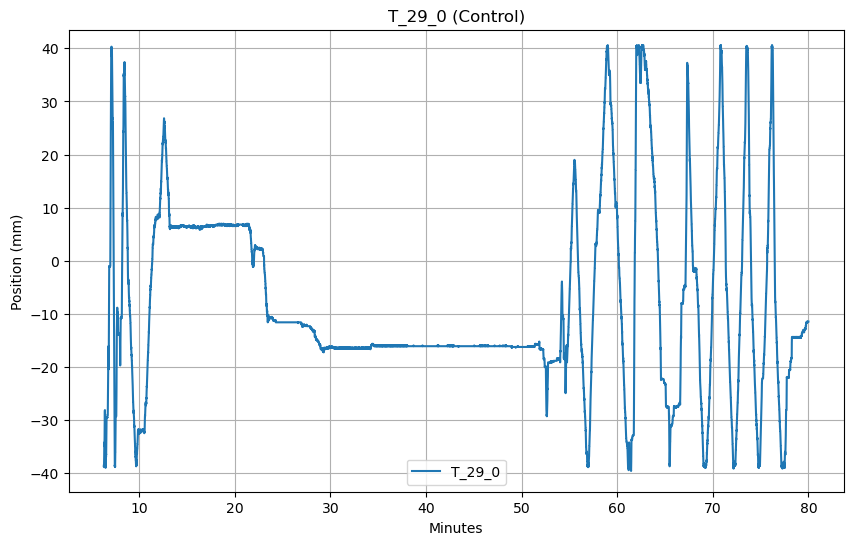

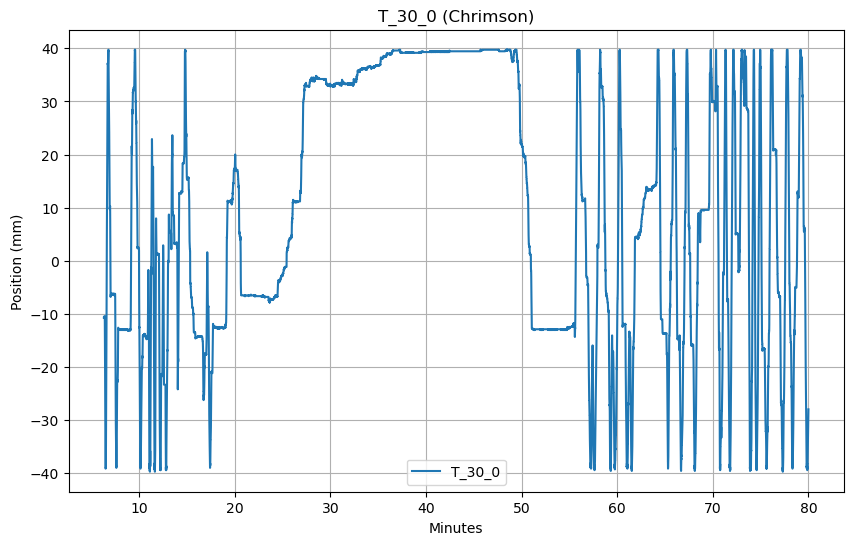

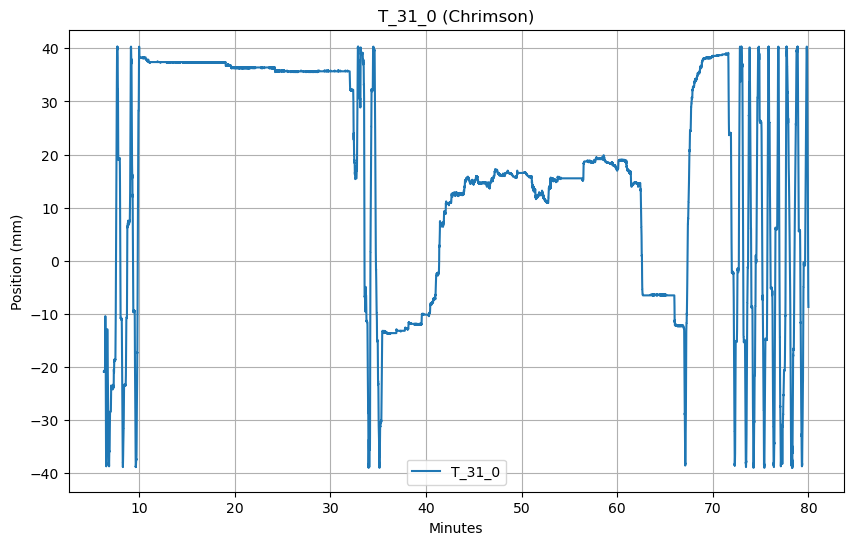

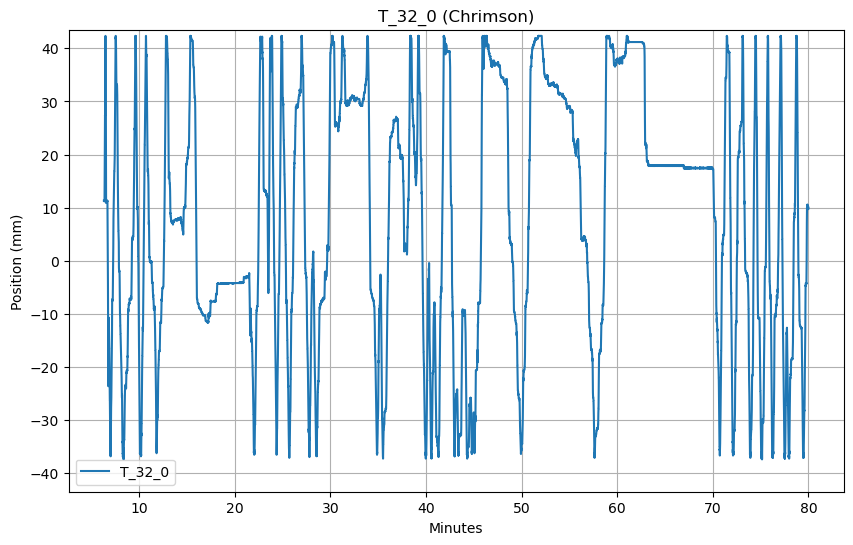

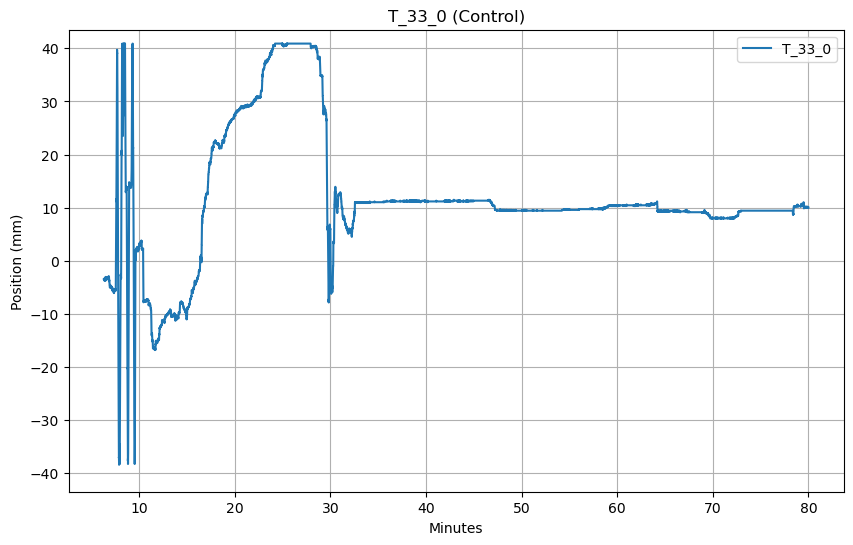

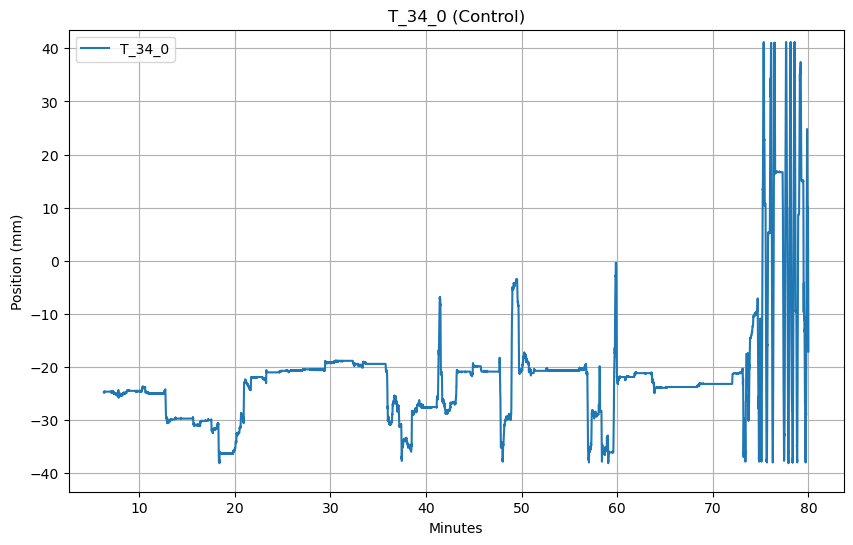

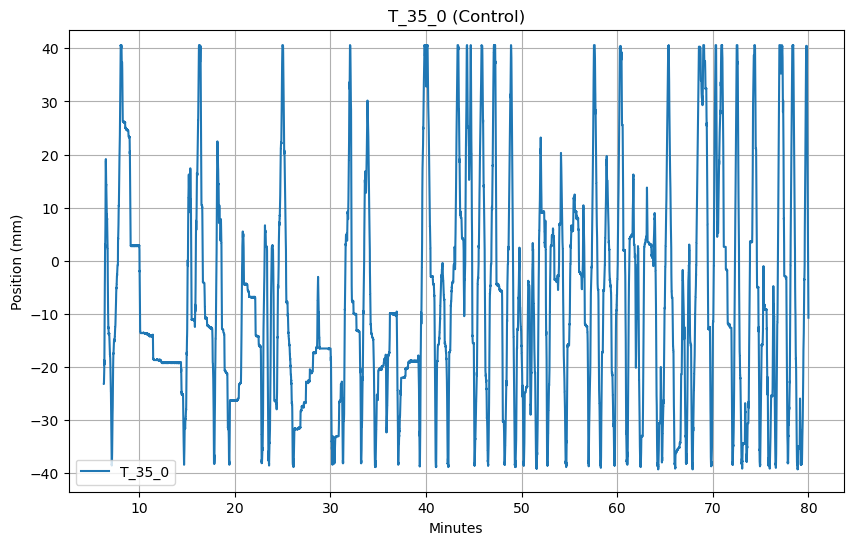

In [16]:
arena.plot_trackers_x()